# Assignment Two — 2025

## Data Preprocessing
- Simple statistical evaluation of the data set;
- Identify the target variable(s);
- Identify if this is a regression or a classification task;
- Are there any missing data? What can you do about them?
- Which variables are relevant or irrelevant to the task?
- What type of validation/cross-validation procedure will you use? 
- Data visualisation.

In [ ]:
# Install Package 
import numpy as np, seaborn as sns, matplotlib.pyplot as plt

import numpy as np
from numpy.random import normal

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

import seaborn as sns
import math

# Data splitting and model evaluation
from sklearn.model_selection import train_test_split, KFold, cross_val_score    
from sklearn.linear_model import LinearRegression, LassoCV, Lasso
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import  StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
# Loading the data
data = pd.read_csv("Euro_6_latest.csv", 
                   encoding= 'latin1') # encoding = 'latin1' is required because in the dataset, 
                                       # there are special characters. Latin1 is an encoding for Western Europe. 
data.head()
# From the data.head() code, we see that there are 45 columns. However, in this dataset, the last column is 'unnamed:44' and there is no values in this column. 
# This is because the last column in the original dataset is 'Date of change' with a comma, thus, the pandas see it as a column and include it. Thus, this last column should be slided out.
# After the initial understanding of the meaning of each column in this dataset, the first three columns 'Manufacturere', 'Model', and 'Description', 'Noise Level dB (A)'


# Moreover, from the initial assessment, as the topic focuses on the car and emission, 'Noise Level dB (A)' is not relevant and it should be also dropped. 
# Similarly, 'Date of Change' column appears simply as an updated date of each row. Hence, it is dropped.

#

,Manufacturer,Model,Description,Transmission,Manual or Automatic,Engine Capacity,Fuel Type,Powertrain,Engine Power (PS),Engine Power (Kw),...,Electric Range City Km,Emissions CO [mg/km],THC Emissions [mg/km],Emissions NOx [mg/km],THC + NOx Emissions [mg/km],Particulates [No.] [mg/km],RDE NOx Urban,RDE NOx Combined,Noise Level dB(A),Date of change
0,ABARTH,500e MY23/24,114kW Electric (VL),A1,Electric - Not Applicable,0.0,Electricity,Battery Electric Vehicle (BEV) / Pure Electric...,155.0,114.0,...,359.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,68.0,17-Oct-24
1,ABARTH,500e MY23/24,114kW Electric (VH),A1,Electric - Not Applicable,0.0,Electricity,Battery Electric Vehicle (BEV) / Pure Electric...,155.0,114.0,...,330.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,68.0,17-Oct-24
2,ABARTH,500e MY23/24,114kW Electric Convertible (VL),A1,Electric - Not Applicable,0.0,Electricity,Battery Electric Vehicle (BEV) / Pure Electric...,155.0,114.0,...,359.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,68.0,17-Oct-24
3,ABARTH,500e MY23/24,114kW Electric Convertible (VH),A1,Electric - Not Applicable,0.0,Electricity,Battery Electric Vehicle (BEV) / Pure Electric...,155.0,114.0,...,330.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,68.0,17-Oct-24
4,ABARTH,595 MY23,Turismo 1.4 Tjet 165 hp Manual (VL),M5,Manual,1368.0,Petrol,Internal Combustion Engine (ICE),165.0,121.0,...,NaN,688.0,66.0,28.0,NaN,NaN,60.0,60.0,69.0,17-Oct-24


In [ ]:
print(f"Original data shape: {data.shape}")
print(f"Data rows: {data.shape[0]}, Data columns: {data.shape[1]}")

Original data shape: (3702, 44)
Data rows: 3702, Data columns: 44


In [ ]:
data.dtypes
# only data type for column 'Date of change' is not at the right match while the rest is correct. 

Manufacturer                              object
Model                                     object
Description                               object
Transmission                              object
Manual or Automatic                       object
Engine Capacity                          float64
Fuel Type                                 object
Powertrain                                object
Engine Power (PS)                        float64
Engine Power (Kw)                        float64
Electric energy consumption Miles/kWh    float64
wh/km                                    float64
Maximum range (Km)                       float64
Maximum range (Miles)                    float64
Euro Standard                             object
Diesel VED Supplement                       bool
Testing Scheme                            object
WLTP Imperial Low                        float64
WLTP Imperial Medium                     float64
WLTP Imperial High                       float64
WLTP Imperial Extra 

In [ ]:
# Count the number of N/A values in each column
def count_na(data):
    number_of_columns = data.shape[1]
    for i in range(number_of_columns):
        col_name = data.columns[i]
        count = data[col_name].isna().sum()
        print(f"The number of NA values in column '{col_name}' is {count}")
count_na(data)

The number of NA values in column 'Manufacturer' is 0
The number of NA values in column 'Model' is 0
The number of NA values in column 'Description' is 0
The number of NA values in column 'Transmission' is 558
The number of NA values in column 'Manual or Automatic' is 0
The number of NA values in column 'Engine Capacity' is 2
The number of NA values in column 'Fuel Type' is 0
The number of NA values in column 'Powertrain' is 0
The number of NA values in column 'Engine Power (PS)' is 19
The number of NA values in column 'Engine Power (Kw)' is 8
The number of NA values in column 'Electric energy consumption Miles/kWh' is 883
The number of NA values in column 'wh/km' is 2516
The number of NA values in column 'Maximum range (Km)' is 2375
The number of NA values in column 'Maximum range (Miles)' is 2702
The number of NA values in column 'Euro Standard' is 0
The number of NA values in column 'Diesel VED Supplement' is 0
The number of NA values in column 'Testing Scheme' is 0
The number of NA

In [ ]:
# Examine categorical data from Manufacturer columns
manufacturer_types = data["Manufacturer"].unique()
print(f"Unique fuel types: {manufacturer_types}")
print(f"Number of categories: {len(manufacturer_types)}")

Unique fuel types: ['ABARTH' 'ALFA ROMEO' 'ALPINE' 'ASTON MARTIN LAGONDA' 'BENTLEY MOTORS'
 'CADILLAC' 'CHEVROLET' 'CHRYSLER JEEP' 'CITROEN' 'DACIA' 'DS' 'FERRARI'
 'FIAT' 'FORD' 'GENESIS' 'GWM' 'HONDA' 'HYUNDAI' 'INEOS Automotive Ltd'
 'KGM UK Motors Ltd' 'KIA' 'LEXUS' 'LOTUS' 'MASERATI' 'MAZDA' 'McLaren'
 'MERCEDES-BENZ' 'MG MOTORS UK' 'MORGAN MOTOR COMPANY' 'NISSAN' 'PEUGEOT'
 'PORSCHE' 'RENAULT' 'Rolls Royce' 'SEAT' 'Smart UK Automotive Ltd'
 'SUBARU' 'SUZUKI' 'TESLA' 'TOYOTA' 'VAUXHALL' 'VOLVO' 'XPENG']
Number of categories: 43


In [ ]:
# Examine categorical data from Fuel Type column
fuel_type_categories = data["Fuel Type"].unique()
print(f"Unique fuel types: {fuel_type_categories}")
print(f"Number of categories: {len(fuel_type_categories)}")

Unique fuel types: ['Electricity' 'Petrol' 'Diesel' 'Electricity / Petrol' 'Petrol Electric'
 'Petrol / LPG' 'Diesel Electric' 'Electricity / Diesel']
Number of categories: 8


Text(0.5, 1.0, 'Average CO2 Emissions by Fuel Type')

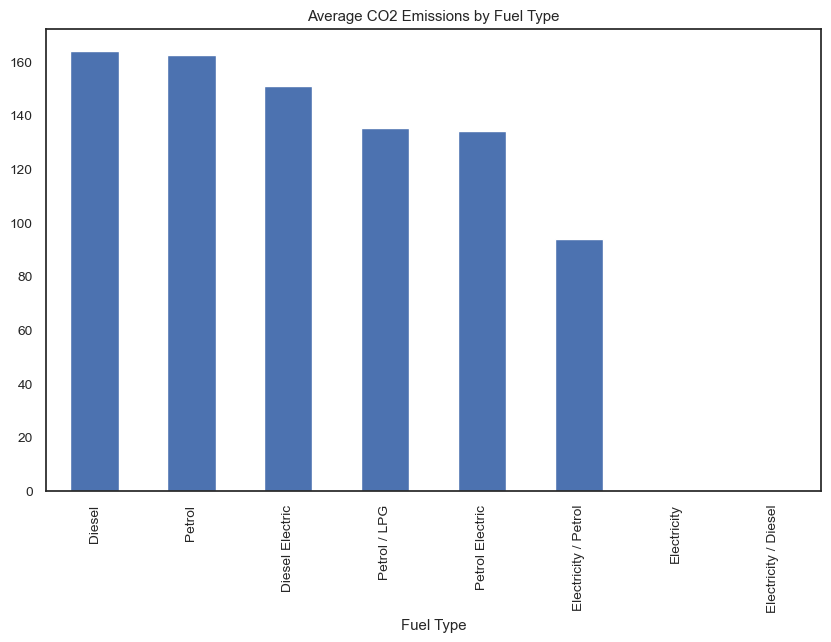

In [ ]:
data.groupby("Fuel Type")["WLTP CO2"].mean().sort_values(ascending=False).plot(kind="bar", figsize=(10,6))
plt.title("Average CO2 Emissions by Fuel Type")

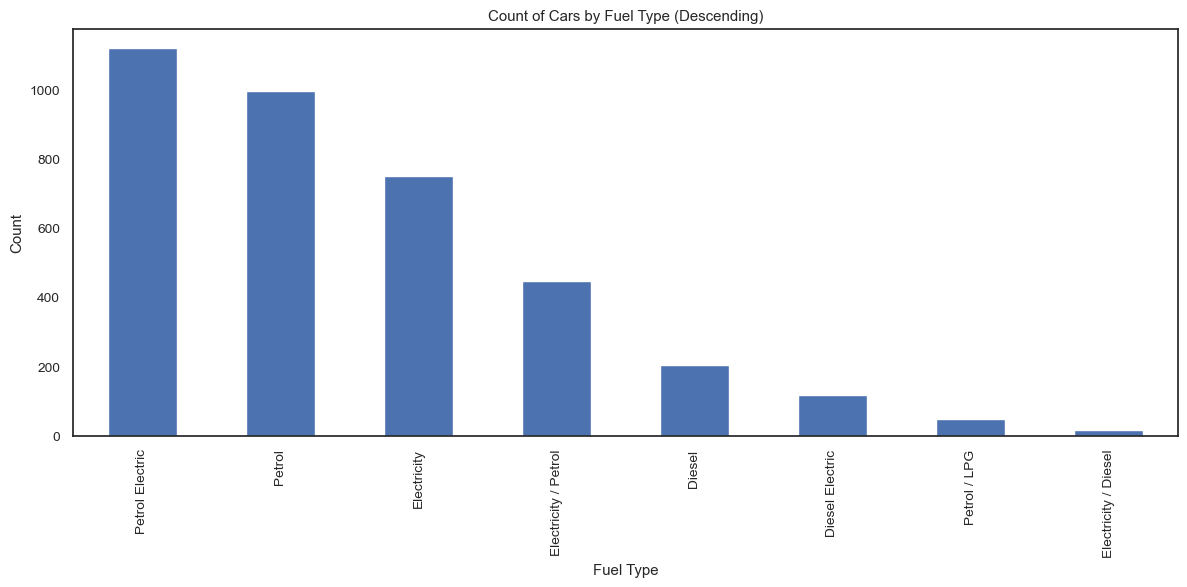

In [ ]:
fuel_type_counts = data["Fuel Type"].value_counts().reindex(fuel_type_categories, fill_value=0)
sorted_counts = fuel_type_counts.sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sorted_counts.plot(kind="bar")
plt.title("Count of Cars by Fuel Type (Descending)")
plt.ylabel("Count")
plt.xlabel("Fuel Type")
plt.tight_layout()

plt.show()

Text(0.5, 1.0, 'Average NOx Emissions by Fuel Type')

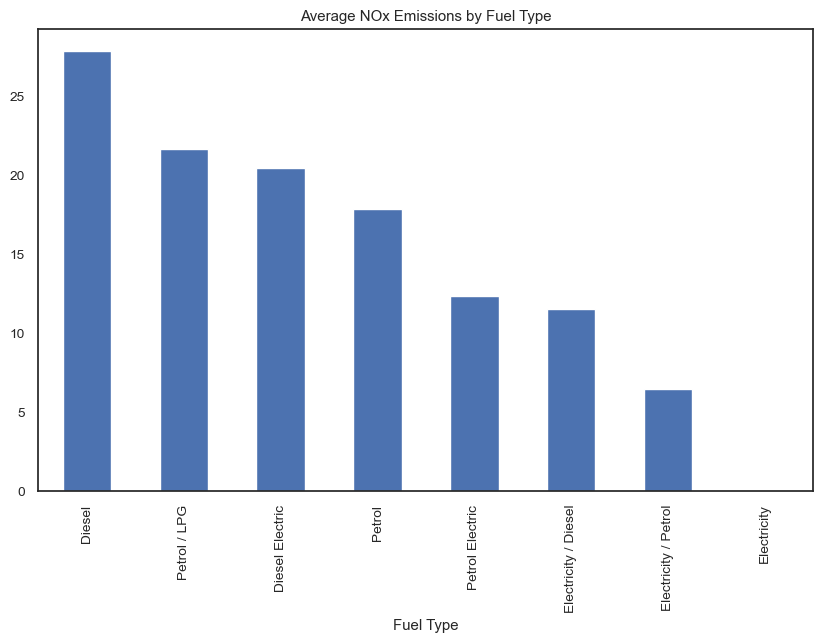

In [ ]:
data.groupby("Fuel Type")["Emissions NOx [mg/km]"].mean().sort_values(ascending=False).plot(kind="bar", figsize=(10,6))
plt.title("Average NOx Emissions by Fuel Type")

Correlation between Engine Capacity and Emissions NOx: 0.002769031929153689


/var/folders/k8/h3hx38g935j55dgsg36nyw5w0000gn/T/ipykernel_7160/2217262933.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Fuel Type", bbox_to_anchor=(1.05, 1), loc='upper left')


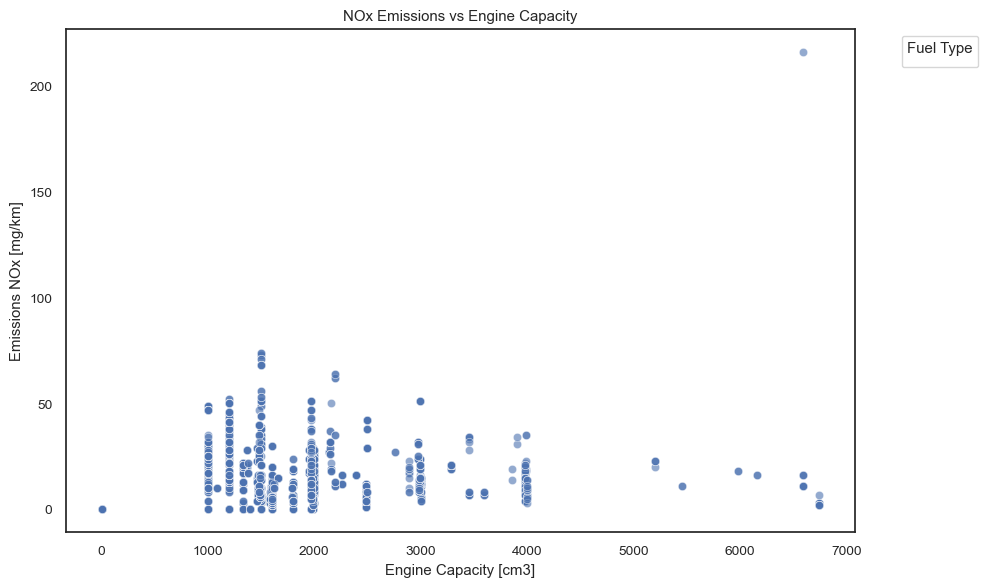

In [ ]:
# Examine relationships between NOx emissions and engine capacity
correlation = data["Engine Capacity"].corr(data["Emissions NOx [mg/km]"])
print(f"Correlation between Engine Capacity and Emissions NOx: {correlation}")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x="Engine Capacity", y="Emissions NOx [mg/km]", alpha=0.6)
plt.title("NOx Emissions vs Engine Capacity")
plt.xlabel("Engine Capacity [cm3]")
plt.ylabel("Emissions NOx [mg/km]")
plt.legend(title="Fuel Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/var/folders/k8/h3hx38g935j55dgsg36nyw5w0000gn/T/ipykernel_7160/4130870419.py:24: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/opt/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


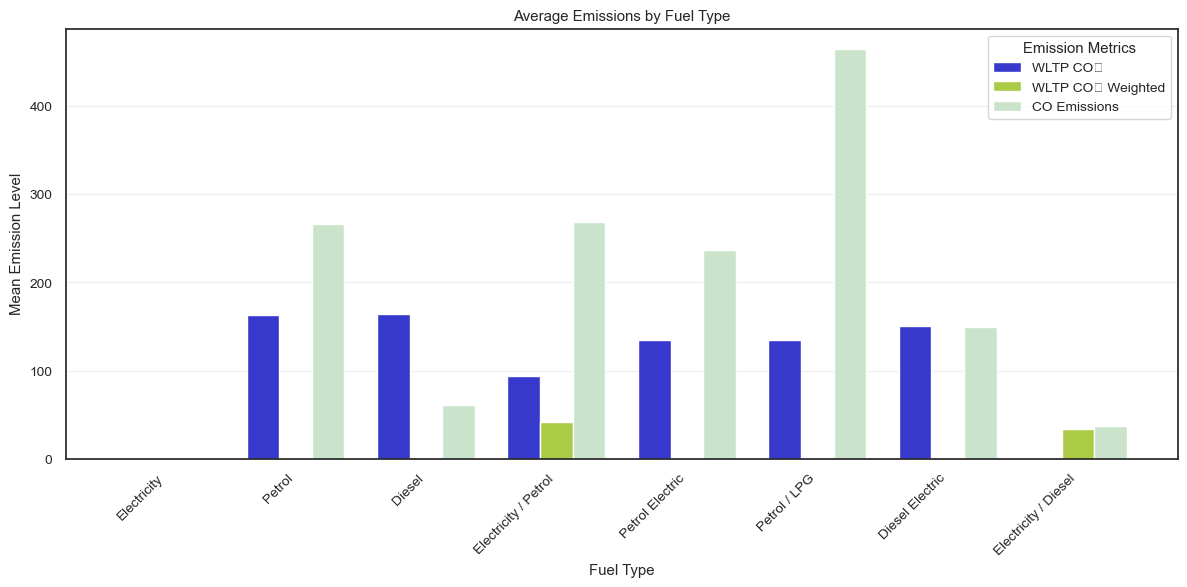

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Step 1. Compute mean emissions per fuel type
metrics = ["WLTP CO2", "WLTP CO2 Weighted", "Emissions CO [mg/km]"]
emission_means = data.groupby("Fuel Type")[metrics].mean().reindex(fuel_type_categories)

# Step 2. Plot grouped bar chart
x = np.arange(len(emission_means.index))  # positions for each fuel type
width = 0.25  # width of each bar

plt.figure(figsize=(12, 6))

plt.bar(x - width, emission_means["WLTP CO2"], width, label="WLTP CO₂", color="#3639CC")
plt.bar(x, emission_means["WLTP CO2 Weighted"], width, label="WLTP CO₂ Weighted", color="#ABCA45")
plt.bar(x + width, emission_means["Emissions CO [mg/km]"], width, label="CO Emissions", color="#C9E4CA")

plt.xticks(x, emission_means.index, rotation=45, ha='right')
plt.title("Average Emissions by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Mean Emission Level")
plt.legend(title="Emission Metrics")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


**Conclusion**
Pick WLTP CO2 due to: 
- have enough data accross different fuel types. (Despite CO emissions have more, but not common as CO2)
- WLTP CO2 (wegihts) is excluded because it lacked data distrbution accorss fuel types. 
- CO2 is more common to people understanding about gas emissions. 

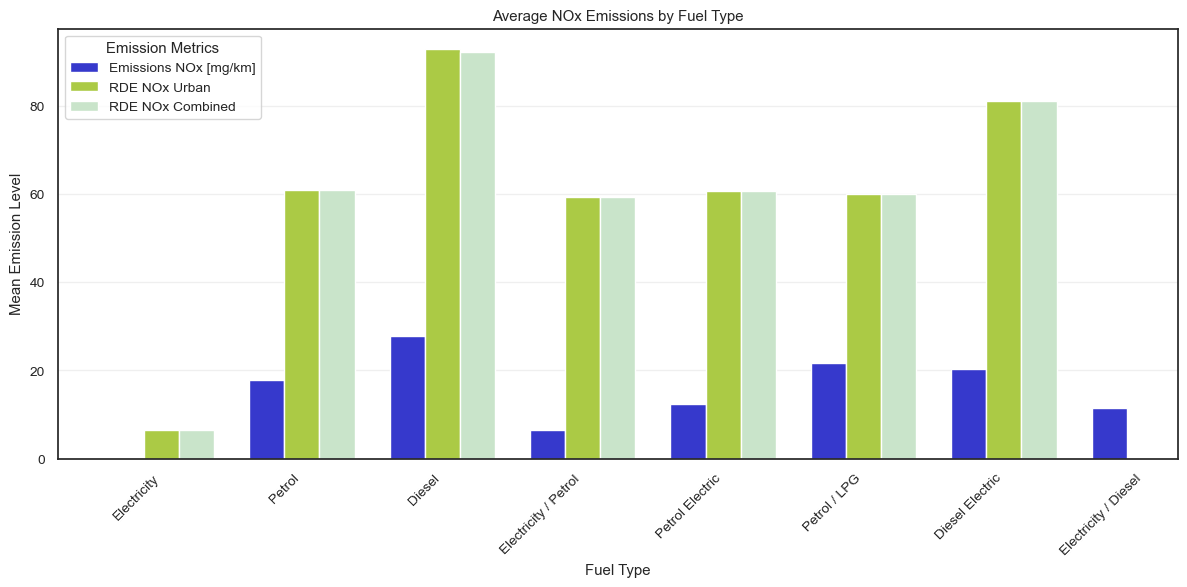

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Step 1. Compute mean emissions per fuel type
metrics = ["Emissions NOx [mg/km]", "RDE NOx Urban", "RDE NOx Combined"]
emission_means = data.groupby("Fuel Type")[metrics].mean().reindex(fuel_type_categories)

# Step 2. Plot grouped bar chart
x = np.arange(len(emission_means.index))  # positions for each fuel type
width = 0.25  # width of each bar

plt.figure(figsize=(12, 6))

plt.bar(x - width, emission_means["Emissions NOx [mg/km]"], width, label="Emissions NOx [mg/km]", color="#3639CC")
plt.bar(x, emission_means["RDE NOx Urban"], width, label="RDE NOx Urban", color="#ABCA45")
plt.bar(x + width, emission_means["RDE NOx Combined"], width, label="RDE NOx Combined", color="#C9E4CA")

plt.xticks(x, emission_means.index, rotation=45, ha='right')
plt.title("Average NOx Emissions by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Mean Emission Level")
plt.legend(title="Emission Metrics")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Pick Emissions NOx [mg/km] because: 
- has difference mean across fuel type -> easier for comparison and prediction afterward.
- RDE NOx Urban and RDE NOx combined are nearly equal across different fuel types. Their mean values are not much different across fuel types. 

Based on the two graphs, eletric cars have no CO2 emissions, and low NOx emissions as well (given the source state that NOx emissions from eletric car are from their battery). Therefore, all of the eletric cars will be excluded from the datasets. 
Given the distribution, two datasets will be created based on their fuel types - fuel cars only (data_fuel), and hybrid cars only (data_hybrid).
Furthermore, since the target variables (WLTP CO2 and NO emissions) are not highly included in Eletricity /Diesel Fuel type, they will be removed from the data_hybrid

In [ ]:
# Examine categorical data from Fuel Type column
fuel_type_categories = data["Fuel Type"].unique()
print(f"Unique fuel types: {fuel_type_categories}")
print(f"Number of categories: {len(fuel_type_categories)}")

Unique fuel types: ['Electricity' 'Petrol' 'Diesel' 'Electricity / Petrol' 'Petrol Electric'
 'Petrol / LPG' 'Diesel Electric' 'Electricity / Diesel']
Number of categories: 8


Based on the visualisation, following variables should be moved since they are not relevant


In [ ]:
removed_variables = [
    "Manufacturer", "Model", "Description",
    "Transmission", "Engine Power (Kw)", "Electric energy consumption Miles/kWh",
    "wh/km", "Maximum range (Km)", "Maximum range (Miles)",
    "Euro Standard", "Diesel VED Supplement", "Testing Scheme", 
    "WLTP CO2 Weighted", "Equivalent All Electric Range Miles", "Equivalent All Electric Range KM",
    "Electric Range City Miles", "Electric Range City Km", "Emissions CO [mg/km]",
    "THC Emissions [mg/km]", "THC + NOx Emissions [mg/km]", "Particulates [No.] [mg/km]",
    "RDE NOx Urban", "RDE NOx Combined", "Noise Level dB(A)", 
    "Date of change",
]

data = data.drop(columns=removed_variables)
print(f"Data shape after removing columns: {data.shape}")

Data shape after removing columns: (3702, 19)


In [ ]:
# Define fuel type categories for each group
# electric_types = ["Electricity"]

hybrid_types = [
    "Electricity / Petrol", "Petrol Electric",
    "Diesel Electric"]

fuel_types = [
    "Petrol", "Diesel", "Petrol / LPG"
]

# Split the dataset
# data_electric = data[data["Fuel Type"].isin(electric_types)] #Can remove since not relevant to the target variable
data_hybrid = data[data["Fuel Type"].isin(hybrid_types)]
data_fuel = data[data["Fuel Type"].isin(fuel_types)]

# print(f"Electric cars: {data_electric.shape[0]} rows")
print(f"Hybrid cars: {data_hybrid.shape[0]} rows")
print(f"Fuel cars: {data_fuel.shape[0]} rows")
# print(f"Original data: {data.shape[0]} rows ") #To check whether the split is correct

Hybrid cars: 1686 rows
Fuel cars: 1250 rows


In [ ]:
# Examine splitted datasets
print(data_fuel.head())
print("\n")
print(data_hybrid.head())

  Manual or Automatic  Engine Capacity Fuel Type  \
4              Manual           1368.0    Petrol   
5              Manual           1368.0    Petrol   
6              Manual           1368.0    Petrol   
7              Manual           1368.0    Petrol   
8              Manual           1368.0    Petrol   

                         Powertrain  Engine Power (PS)  WLTP Imperial Low  \
4  Internal Combustion Engine (ICE)              165.0               28.8   
5  Internal Combustion Engine (ICE)              165.0               27.8   
6  Internal Combustion Engine (ICE)              165.0               28.8   
7  Internal Combustion Engine (ICE)              165.0               27.8   
8  Internal Combustion Engine (ICE)              179.0               26.9   

   WLTP Imperial Medium  WLTP Imperial High  WLTP Imperial Extra High  \
4                  43.3                47.0                      47.0   
5                  42.1                45.5                      38.4   
6    

In [ ]:
#Check and remove NA values in fuel dataset
count_na(data_fuel)
print("\n")
print("Dataset shape before removing NA values:", data_fuel.shape)

data_fuel = data_fuel.dropna()
print("Dataset shape after removing NA values:", data_fuel.shape)

The number of NA values in column 'Manual or Automatic' is 0
The number of NA values in column 'Engine Capacity' is 0
The number of NA values in column 'Fuel Type' is 0
The number of NA values in column 'Powertrain' is 0
The number of NA values in column 'Engine Power (PS)' is 0
The number of NA values in column 'WLTP Imperial Low' is 0
The number of NA values in column 'WLTP Imperial Medium' is 0
The number of NA values in column 'WLTP Imperial High' is 0
The number of NA values in column 'WLTP Imperial Extra High' is 0
The number of NA values in column 'WLTP Imperial Combined' is 0
The number of NA values in column 'WLTP Imperial Combined (Weighted)' is 17
The number of NA values in column 'WLTP Metric Low' is 0
The number of NA values in column 'WLTP Metric Medium' is 0
The number of NA values in column 'WLTP Metric High' is 0
The number of NA values in column 'WLTP Metric Extra High' is 0
The number of NA values in column 'WLTP Metric Combined' is 0
The number of NA values in colum

In [ ]:
#Check and remove NA values in fuel dataset
count_na(data_hybrid)
print("\n")
print("Dataset shape before removing NA values:", data_hybrid.shape)

data_hybrid = data_hybrid.dropna()

print("Dataset shape after removing NA values:", data_hybrid.shape)

The number of NA values in column 'Manual or Automatic' is 0
The number of NA values in column 'Engine Capacity' is 0
The number of NA values in column 'Fuel Type' is 0
The number of NA values in column 'Powertrain' is 0
The number of NA values in column 'Engine Power (PS)' is 0
The number of NA values in column 'WLTP Imperial Low' is 0
The number of NA values in column 'WLTP Imperial Medium' is 0
The number of NA values in column 'WLTP Imperial High' is 0
The number of NA values in column 'WLTP Imperial Extra High' is 0
The number of NA values in column 'WLTP Imperial Combined' is 0
The number of NA values in column 'WLTP Imperial Combined (Weighted)' is 3
The number of NA values in column 'WLTP Metric Low' is 0
The number of NA values in column 'WLTP Metric Medium' is 0
The number of NA values in column 'WLTP Metric High' is 0
The number of NA values in column 'WLTP Metric Extra High' is 0
The number of NA values in column 'WLTP Metric Combined' is 0
The number of NA values in column

### Statistical Analysis

In [ ]:
# Review Mean, Min, Max, SD of data
data.describe()

,Engine Capacity,Engine Power (PS),WLTP Imperial Low,WLTP Imperial Medium,WLTP Imperial High,WLTP Imperial Extra High,WLTP Imperial Combined,WLTP Imperial Combined (Weighted),WLTP Metric Low,WLTP Metric Medium,WLTP Metric High,WLTP Metric Extra High,WLTP Metric Combined,WLTP Metric Combined (Weighted),WLTP CO2,Emissions NOx [mg/km]
count,3700.000000,3683.000000,3702.000000,3702.000000,3702.000000,3702.000000,3702.000000,3682.000000,3702.000000,3702.000000,3702.000000,3702.000000,3702.000000,3692.000000,3702.000000,3060.000000
mean,1457.020000,202.254141,29.834414,36.915073,39.302728,31.392410,33.833928,27.268278,6.006213,4.568531,4.219908,5.177120,4.832442,0.242389,111.426526,14.306536
std,1039.860432,127.951896,21.940253,24.854016,25.423989,19.924507,22.184043,80.867074,5.602868,3.344553,3.137791,3.608788,3.482866,0.917002,76.228559,12.533870
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,999.000000,129.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000
50%,1490.000000,160.000000,34.400000,44.800000,50.400000,40.400000,43.300000,0.000000,6.700000,5.200000,4.800000,6.100000,5.600000,0.000000,129.000000,12.000000
75%,1993.000000,244.000000,42.200000,53.300000,57.600000,46.300000,49.600000,0.000000,8.000000,6.200000,5.600000,6.900000,6.500000,0.000000,148.000000,21.000000
max,6749.000000,1267.000000,100.900000,97.400000,80.700000,68.900000,74.300000,706.300000,193.000000,28.200000,32.500000,42.200000,42.800000,12.400000,380.000000,216.000000


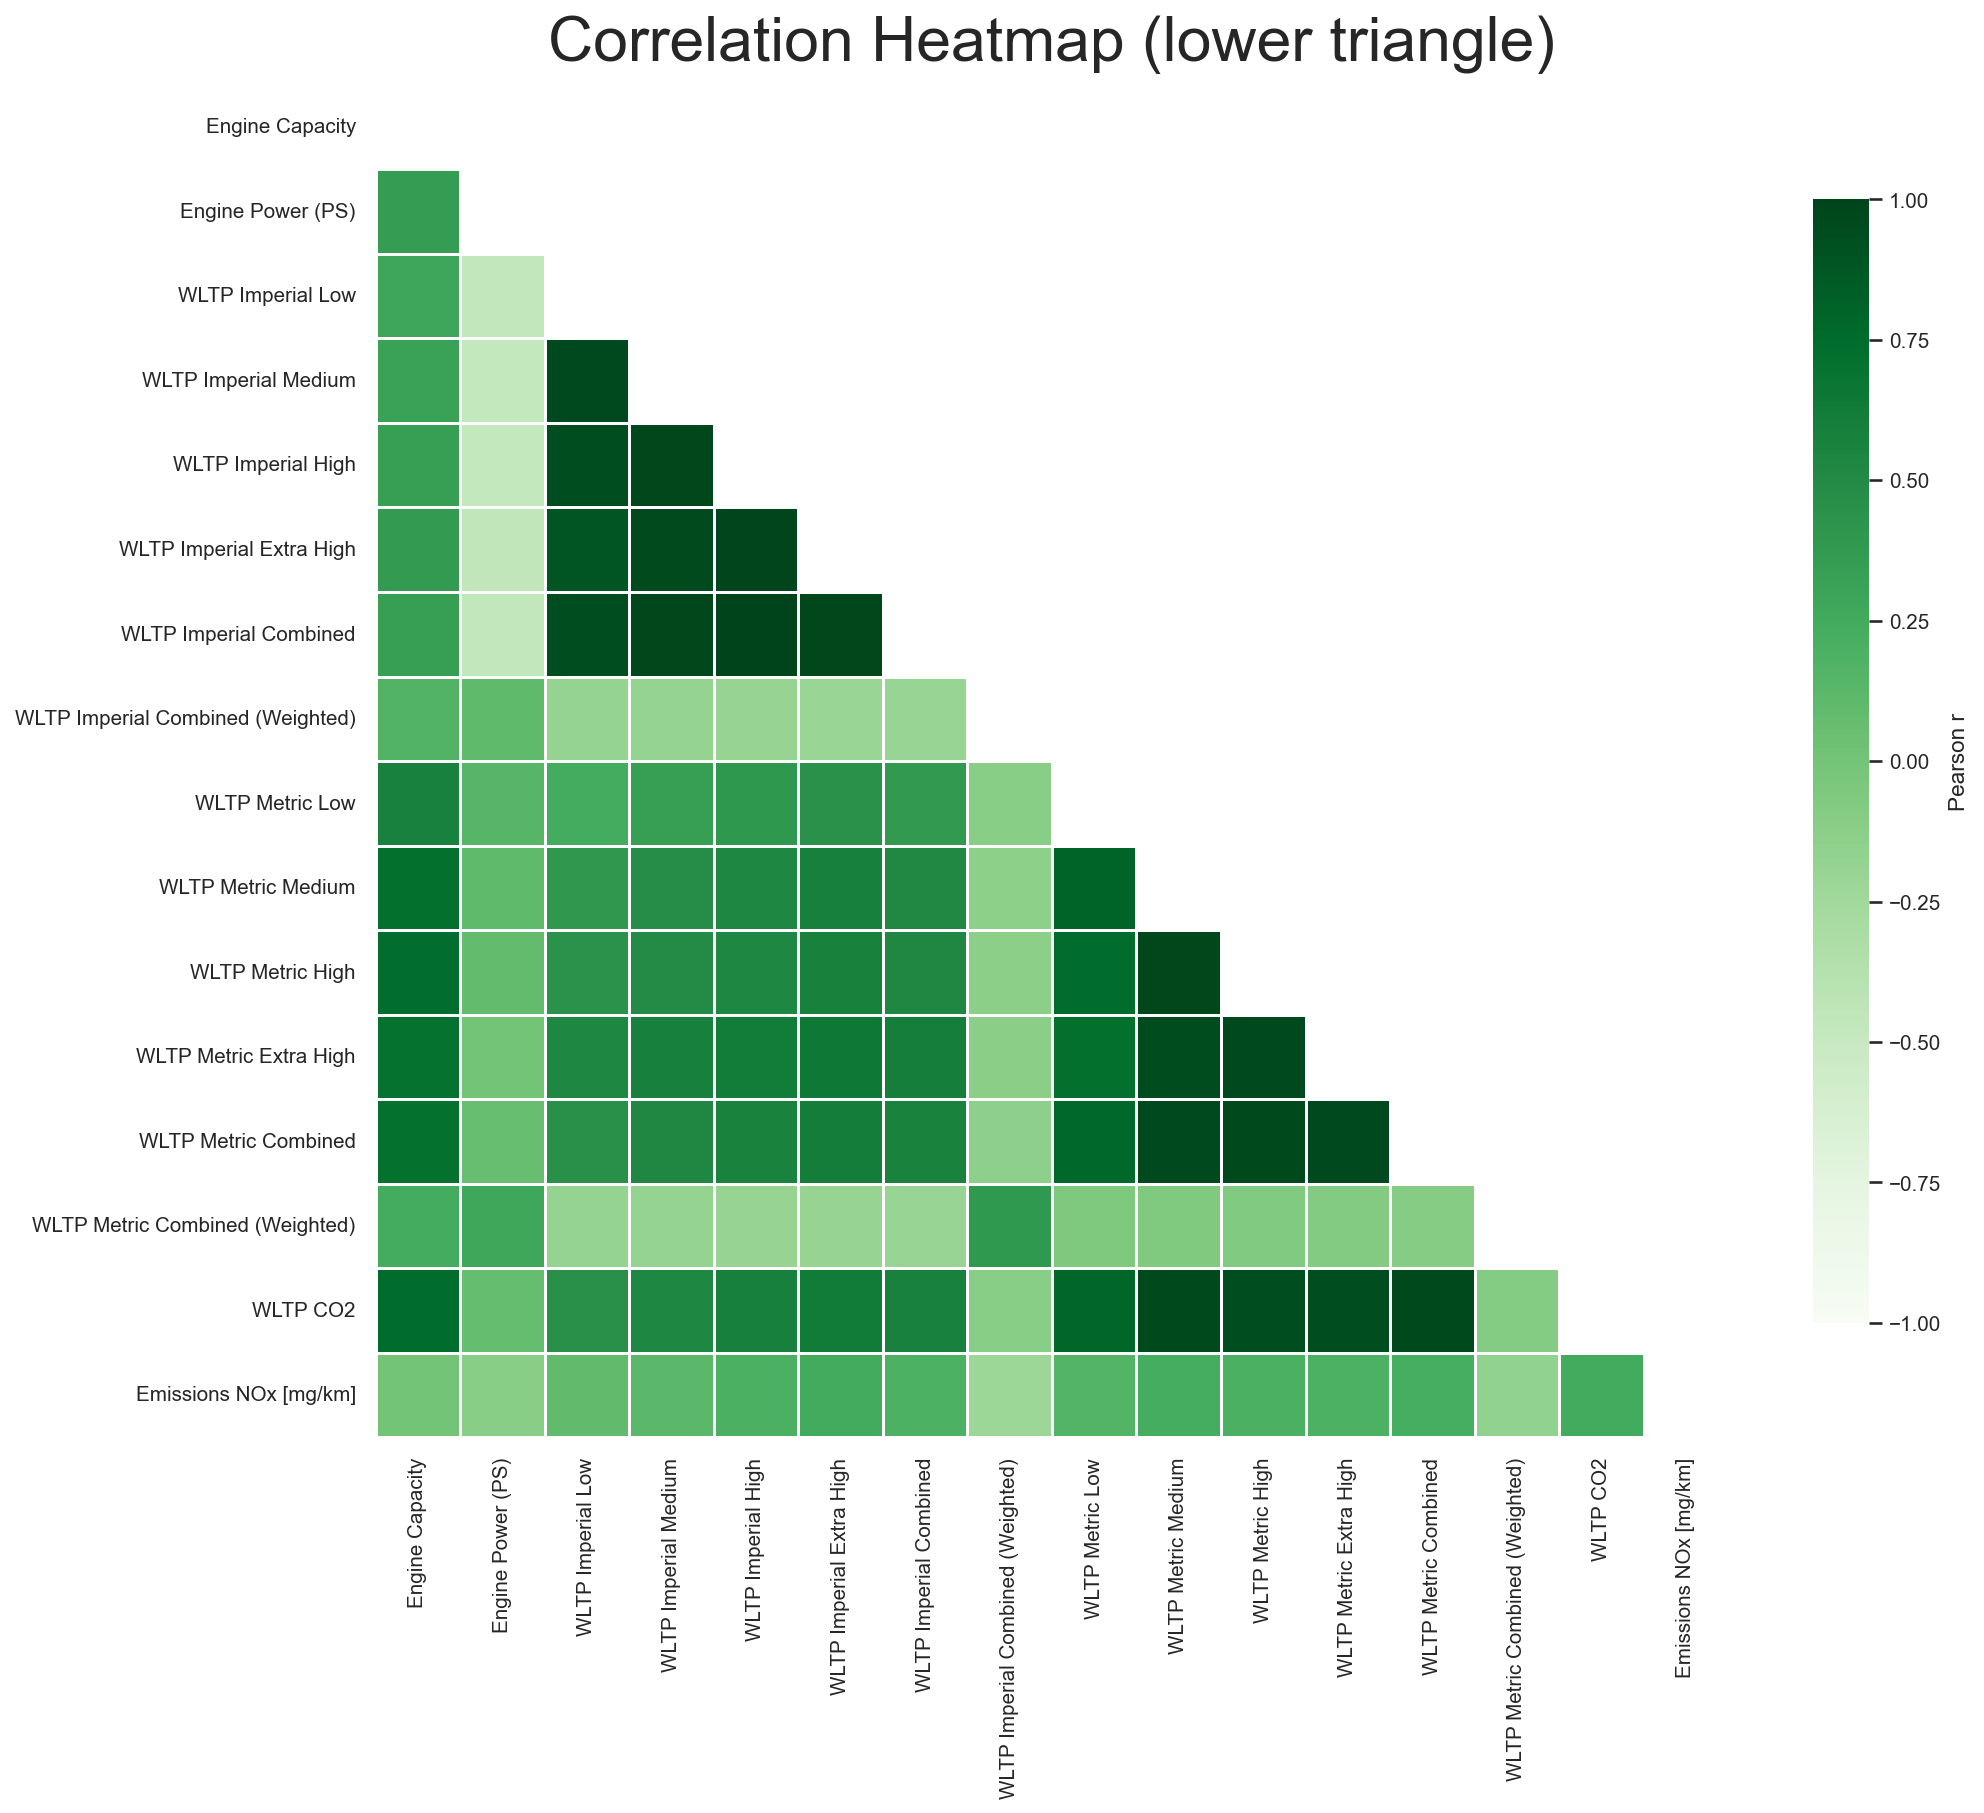

In [ ]:
sns.set_theme(style="white", font_scale=0.9)  # smaller fonts

# Select only numeric columns for computing correlation
numeric_data = data.select_dtypes(include=[np.number])
corr = numeric_data.corr()

# mask the upper triangle (matrix is symmetric)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 12), dpi=150)
ax = sns.heatmap(
    corr, mask=mask, cmap="Greens", vmin=-1, vmax=1, center=0,
    linewidths=.5, linecolor="white",
    cbar_kws=dict(shrink=.8, label="Pearson r"),
    annot=False,  # turn off numbers (too dense)
    square=True
)

ax.set_title("Correlation Heatmap (lower triangle)", fontsize = 30, pad=12)
plt.tight_layout()
plt.show()

Since it is over detailed to visualise the correlation matrix of all variables, only top 20 will be visualised to examine their correlations.

In [ ]:
# Create a function to plot top Correlation values based on the target variable
def plot_top20_correlation(variable:str, data):
    # Set the target variable 
    target = variable

    # numeric-only correlation
    corr = data.select_dtypes(include='number').corr()

    # Extract correlations with target
    target_corr = corr[target].drop(labels=[target])

    # Sort by absolute correlation and take top 20
    top20 = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index).head(20)

    # Plot
    plt.figure(figsize=(8, 7), dpi=150)
    bars = plt.barh(top20.index, top20.values, color='seagreen', edgecolor='black')

    # Add correlation values on bars
    for bar, value in zip(bars, top20.values):
        plt.text(value, bar.get_y() + bar.get_height()/2, f"{value:.2f}",
                ha='left' if value > 0 else 'right', va='center', fontsize=9)


    # Auto labeling based on Fuel Type column
    if data["Fuel Type"].isin(fuel_types).any():
        data_label = "Fuel Cars"
    elif data["Fuel Type"].isin(hybrid_types).any():
        data_label = "Hybrid Cars"
    else:
        data_label = "Dataset"


    plt.axvline(0, color='black', linewidth=0.8)
    plt.title(f"Top 20 Correlations with {target} from {data_label}", fontsize=15, pad=10)
    plt.xlabel("Correlation - Pearson r", fontsize=11)
    plt.ylabel("Variable", fontsize=11)
    plt.gca().invert_yaxis()  # highest correlation on top
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

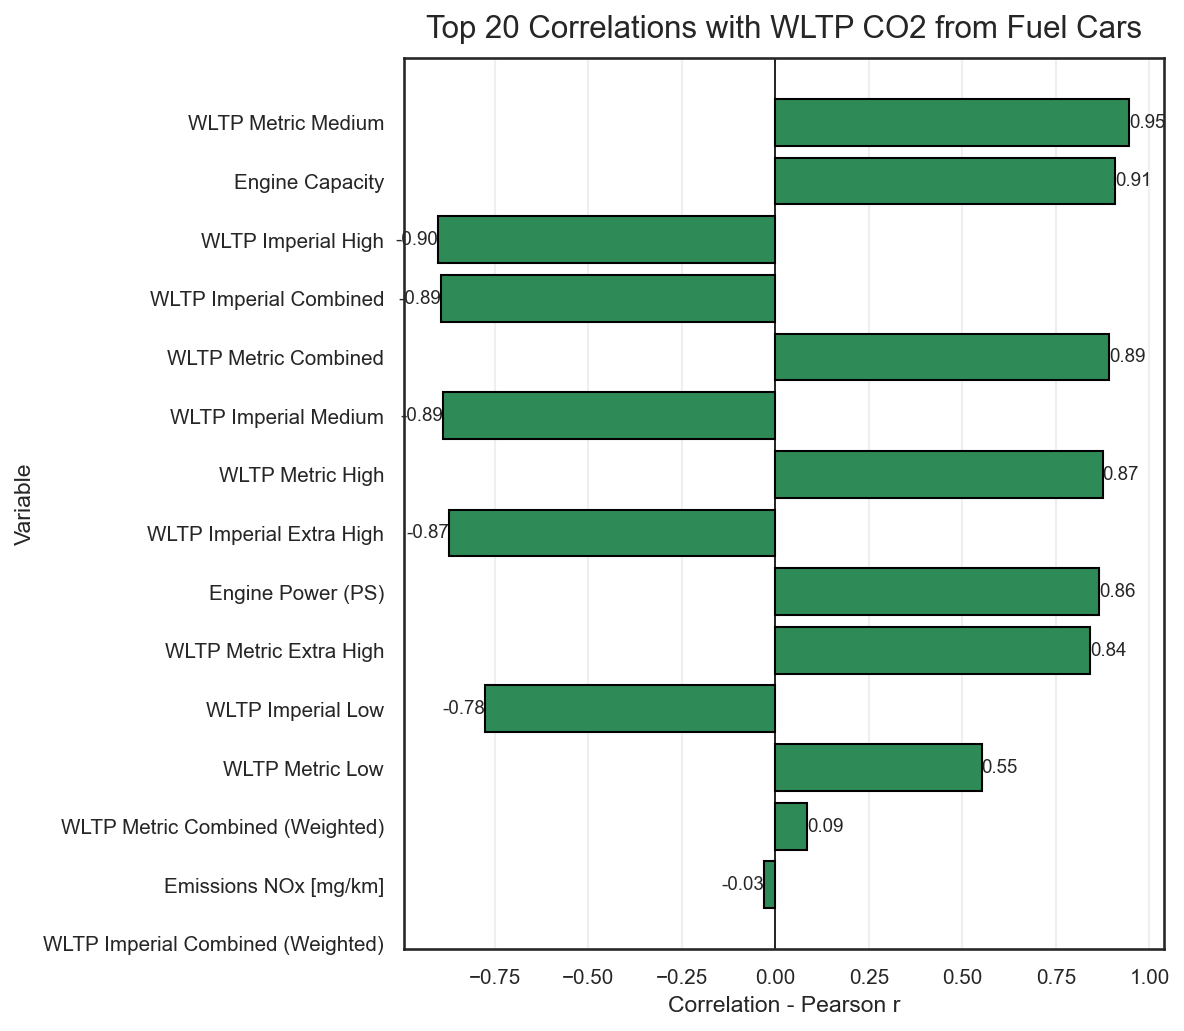

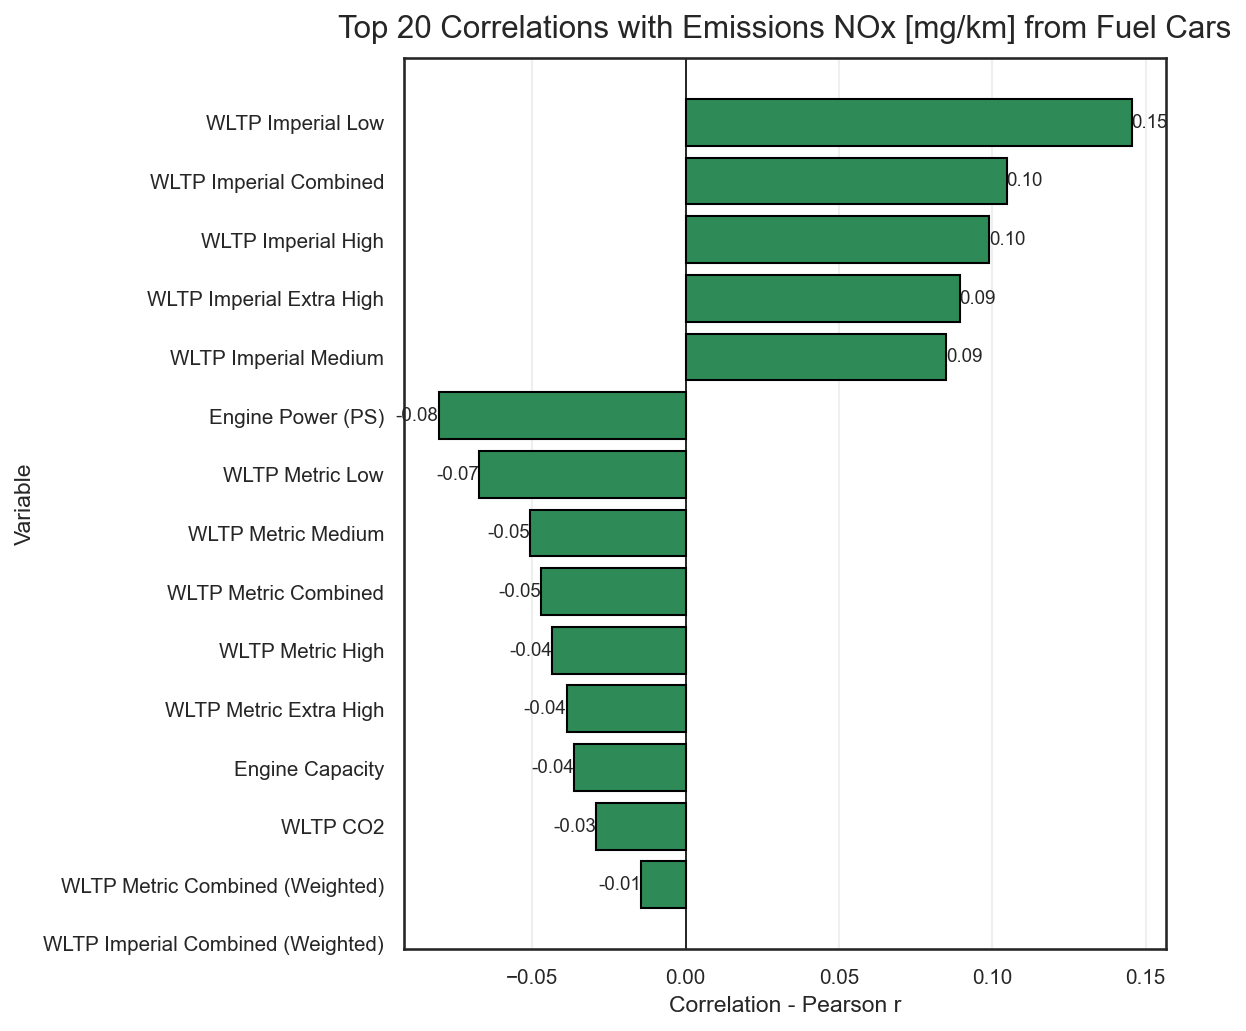

In [ ]:
# -- Correlation Matrix for Fuel Cars
plot_top20_correlation("WLTP CO2", data_fuel)
plot_top20_correlation("Emissions NOx [mg/km]", data_fuel)

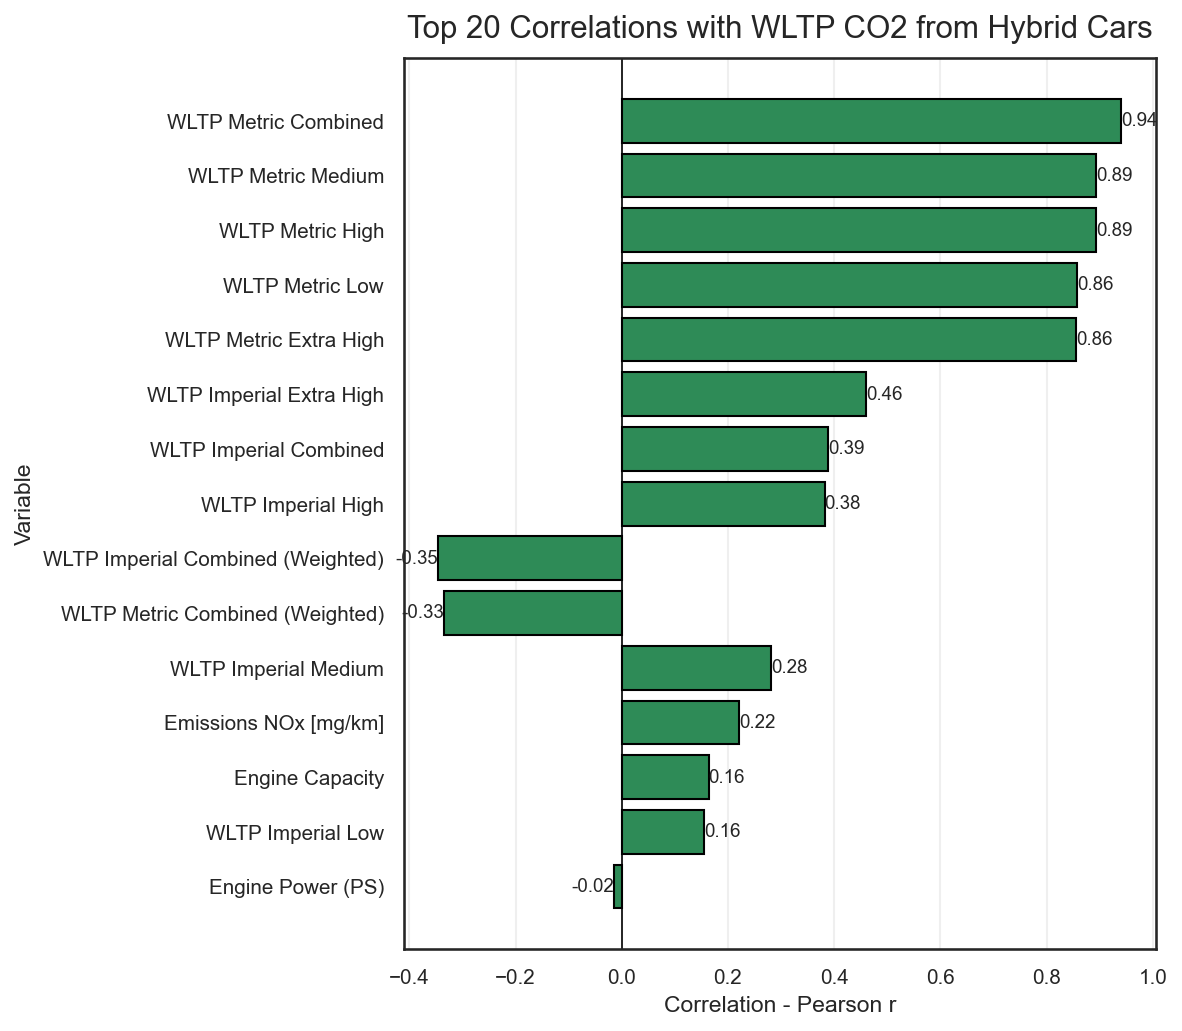

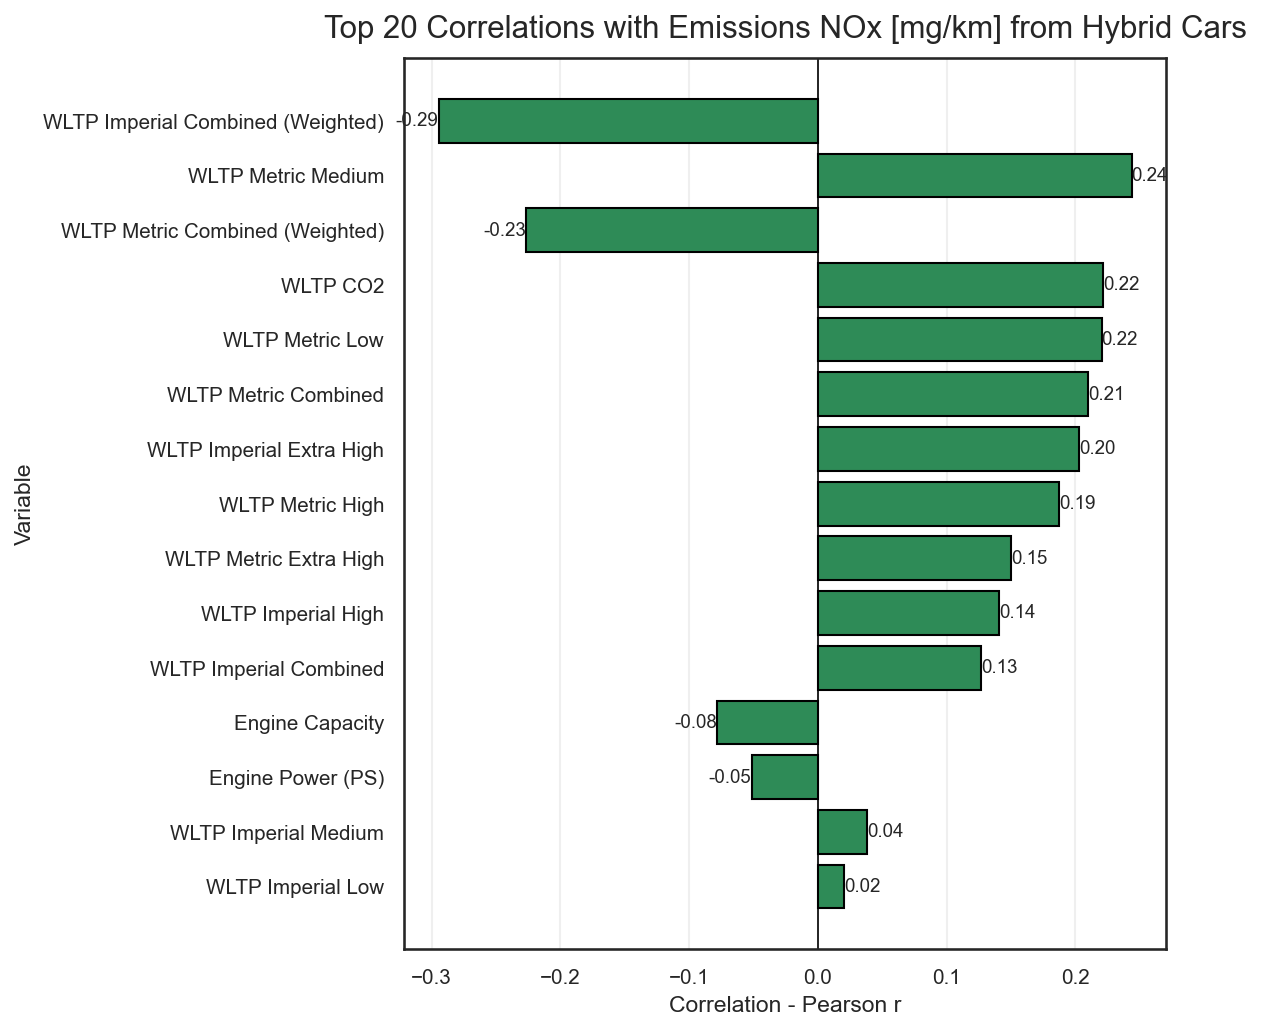

In [ ]:
# -- Correlation Matrix for Hybrid Cars
plot_top20_correlation("WLTP CO2", data_hybrid)
plot_top20_correlation("Emissions NOx [mg/km]", data_hybrid)

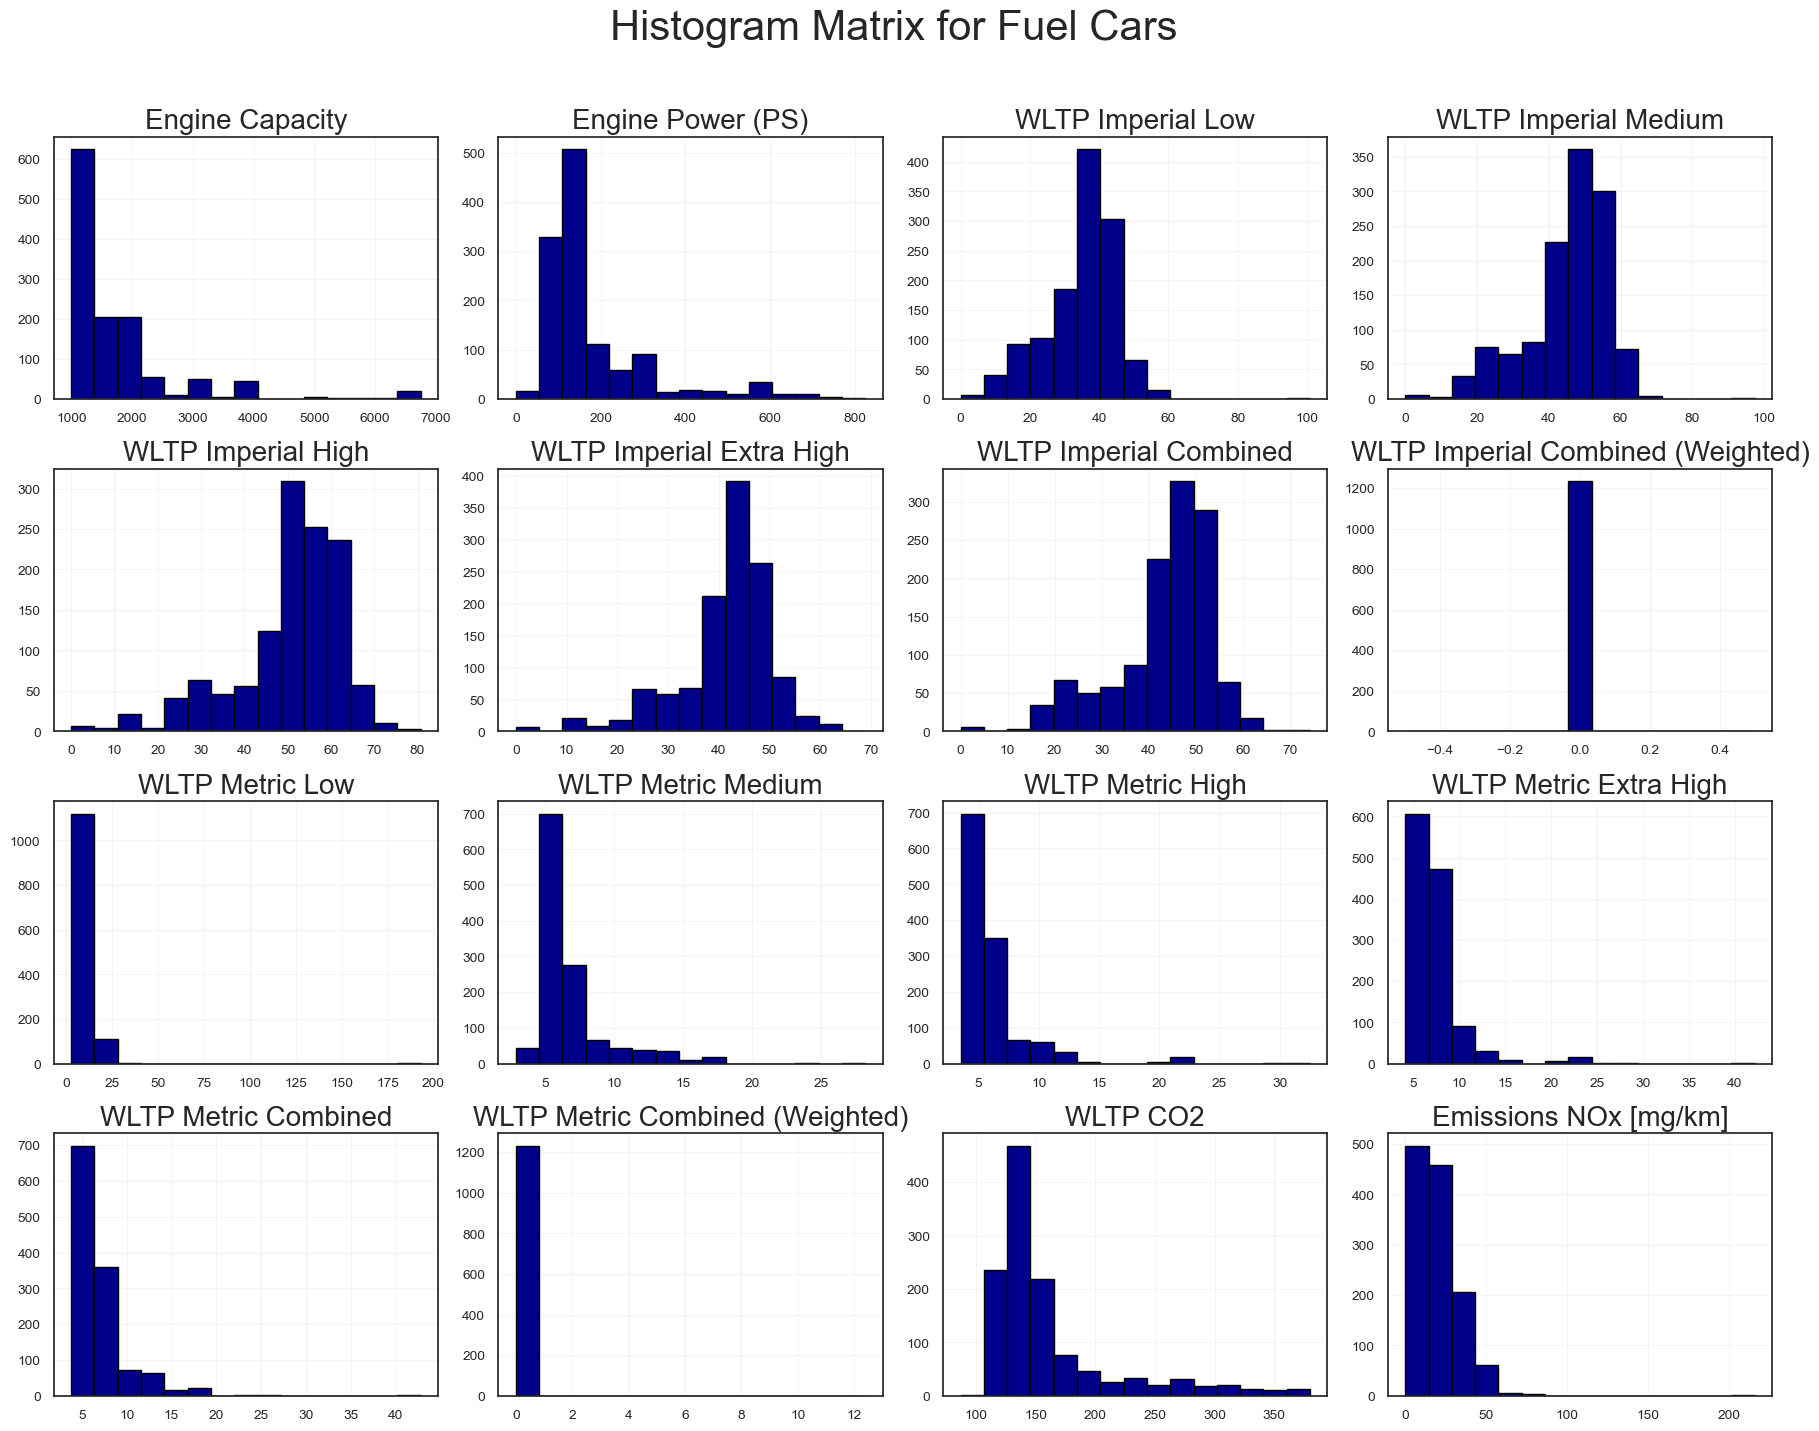

In [ ]:
# -- Histogram Matrix for Fuel Cars --

# Set overall figure size (width, height)
axes = data_fuel.hist(
    figsize=(18, 14),  # larger matrix
    bins=15, # adjust bin count
    color='darkblue',
    edgecolor='black',
    grid=False
)

# Loop over all subplots to format text and labels
for ax in axes.flatten():
    # Bigger titles and smaller axis labels
    ax.set_title(ax.get_title(), fontsize=20)
    ax.set_xlabel(ax.get_xlabel(), fontsize=10)
    ax.set_ylabel(ax.get_ylabel(), fontsize=10)

    ax.grid(alpha=0.3, linewidth=0.5) # thin gridlines for readability

plt.suptitle("Histogram Matrix for Fuel Cars", fontsize=30, y=1.02)
plt.tight_layout()
plt.show()

Remove WLTP Imperial Combined (Weighted) and WLTP Metric Combined (Weighted) due to their unsual distribution.

In [ ]:
# Remove irrelevant columns for regression task
data_fuel = data_fuel.drop(columns=["WLTP Imperial Combined (Weighted)", "WLTP Metric Combined (Weighted)"])
data_fuel.shape

(1233, 17)

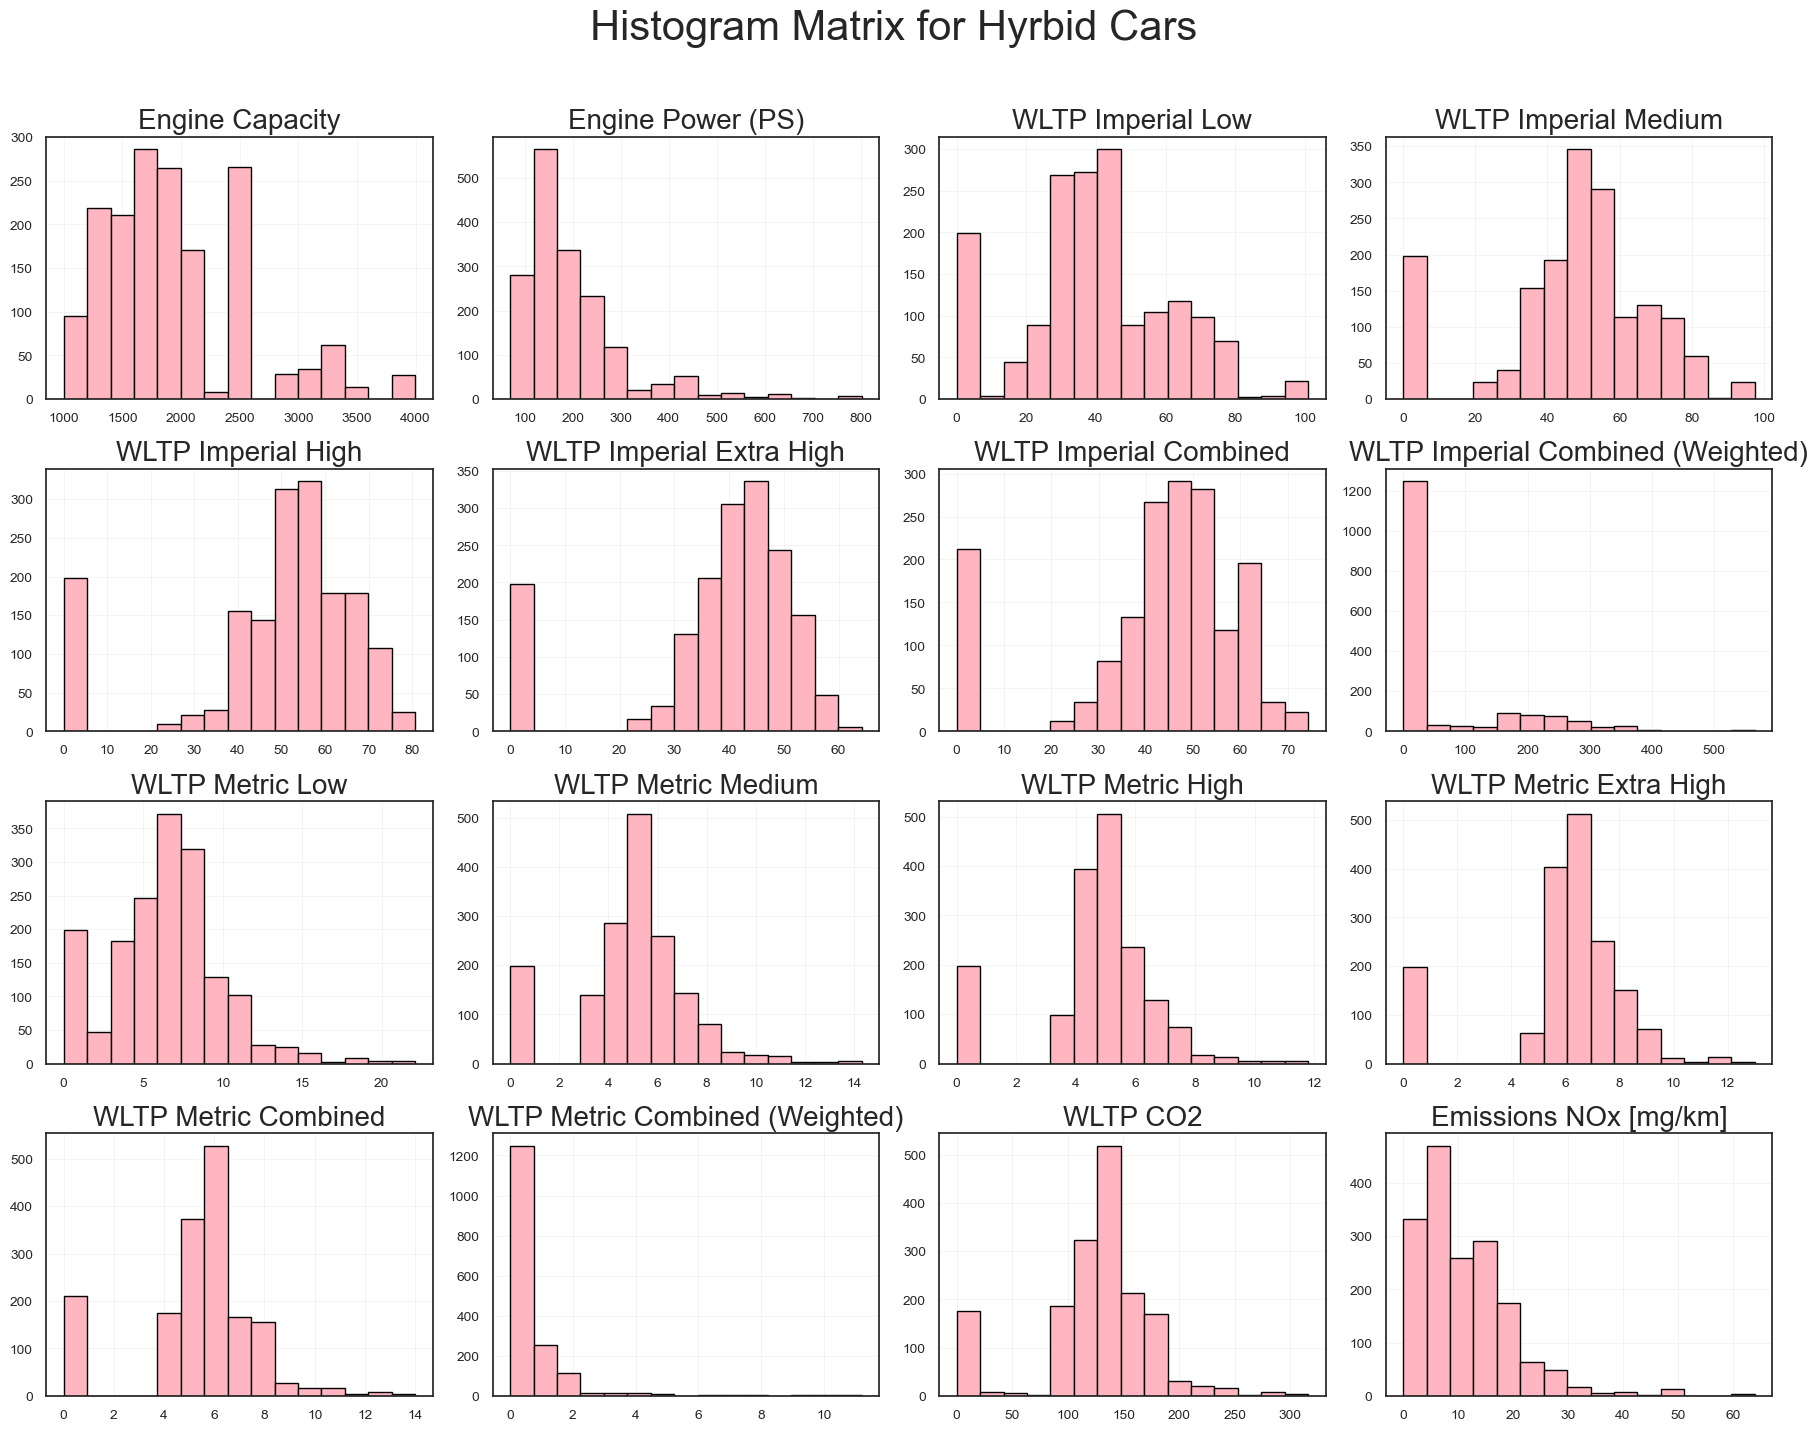

In [ ]:
# -- Histogram Matrix for Hyrbid Cars --

# Set overall figure size (width, height)
axes = data_hybrid.hist(
    figsize=(18, 14),  # larger matrix
    bins=15, # adjust bin count
    color='lightpink',
    edgecolor='black',
    grid=False
)

# Loop over all subplots to format text and labels
for ax in axes.flatten():
    # Bigger titles and smaller axis labels
    ax.set_title(ax.get_title(), fontsize=20)
    ax.set_xlabel(ax.get_xlabel(), fontsize=10)
    ax.set_ylabel(ax.get_ylabel(), fontsize=10)

    ax.grid(alpha=0.3, linewidth=0.5) # thin gridlines for readability

plt.suptitle("Histogram Matrix for Hyrbid Cars", fontsize=30, y=1.02)
plt.tight_layout()
plt.show()

### Outlier Check

Checking outliers on fuel car dataset

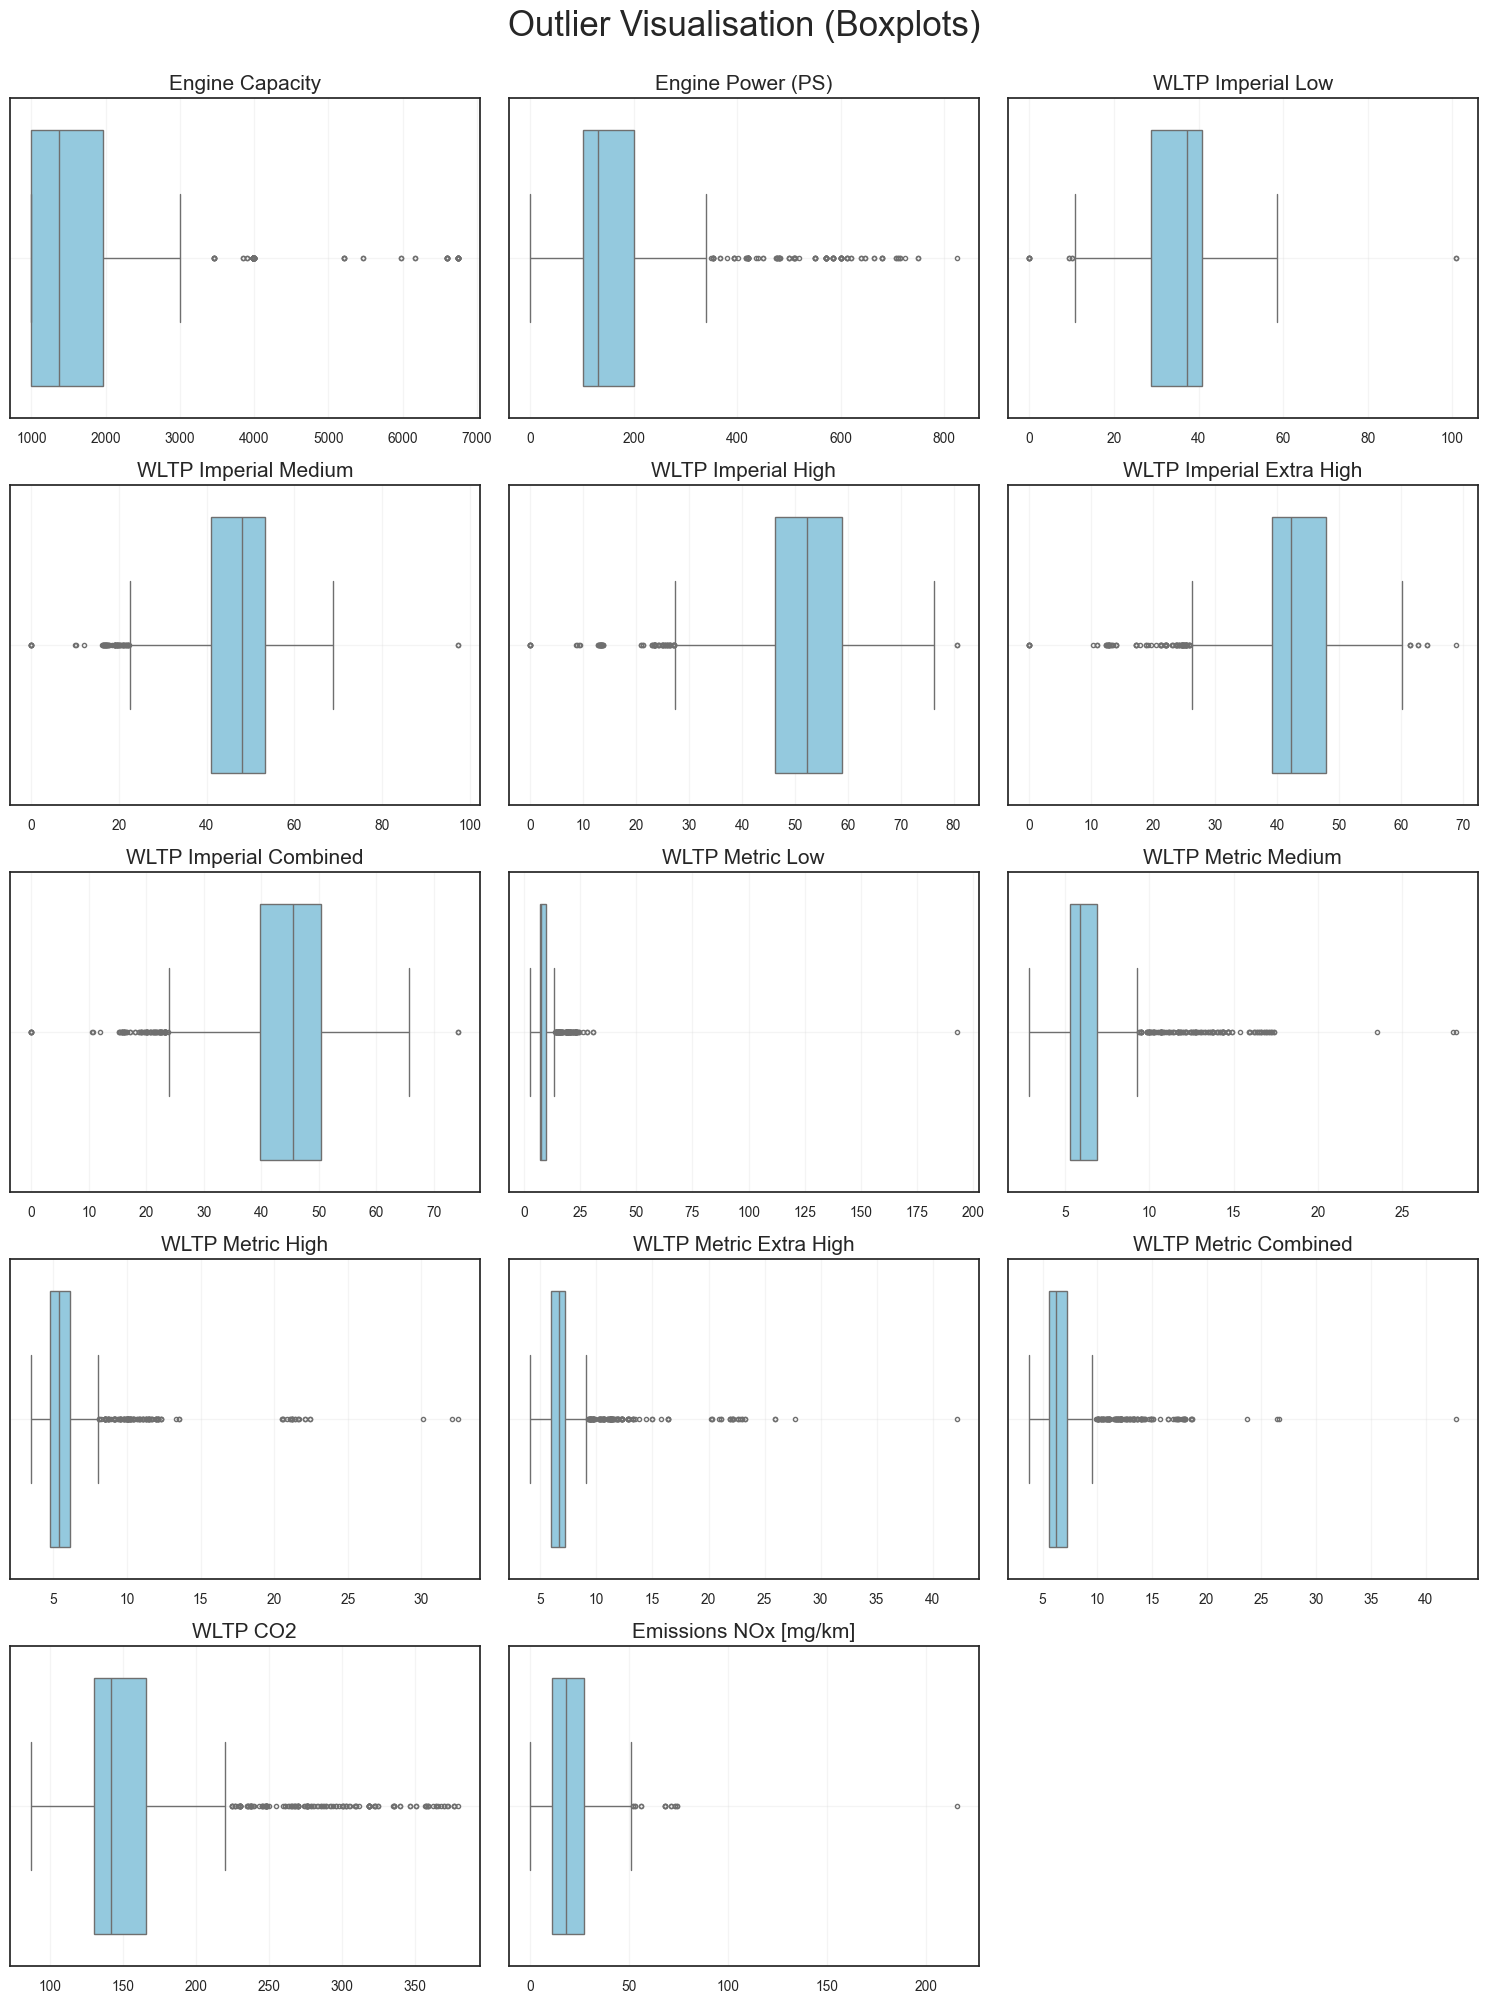

In [1071]:
# A reusable function to visualise outliers, arguments: dataset
def outlier_check(data):
    # Select only numeric columns
    numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    
    if len(numeric_cols) == 0:
        print("No numeric columns found in the dataset.")
        return
    
    # Determine layout
    n_cols = 3
    n_rows = int(np.ceil(len(numeric_cols) / n_cols))
    
    # Set up figure
    plt.figure(figsize=(n_cols * 5, n_rows * 4))
    plt.suptitle("Outlier Visualisation (Boxplots)", fontsize=25, y =1)
    
    # Create boxplots for each numeric column
    for idx, col in enumerate(numeric_cols, 1):
        plt.subplot(n_rows, n_cols, idx)
        sns.boxplot(x=data[col], color='skyblue', fliersize=3, linewidth=1)
        plt.title(col, fontsize=15)
        plt.xlabel("")
        plt.grid(alpha=0.2)
    
    plt.tight_layout()
    plt.show()

outlier_check(data_fuel)

The following variables should be removed from fuel car data since they have high amount of outliers: 

In [1072]:
removed_variables_fuel = [ "WLTP Metric Low", "WLTP Metric Medium",
                            "WLTP Metric High", "WLTP Metric Extra High",
                            "WLTP Metric Combined" ]

print(f"Data shape before removing columns: {data_fuel.shape}")

data_fuel = data_fuel.drop(columns=removed_variables_fuel)
print(f"Data shape after removing columns: {data_fuel.shape}")

Data shape before removing columns: (1233, 17)
Data shape after removing columns: (1233, 12)


Checking outliers on hybrid car dataset

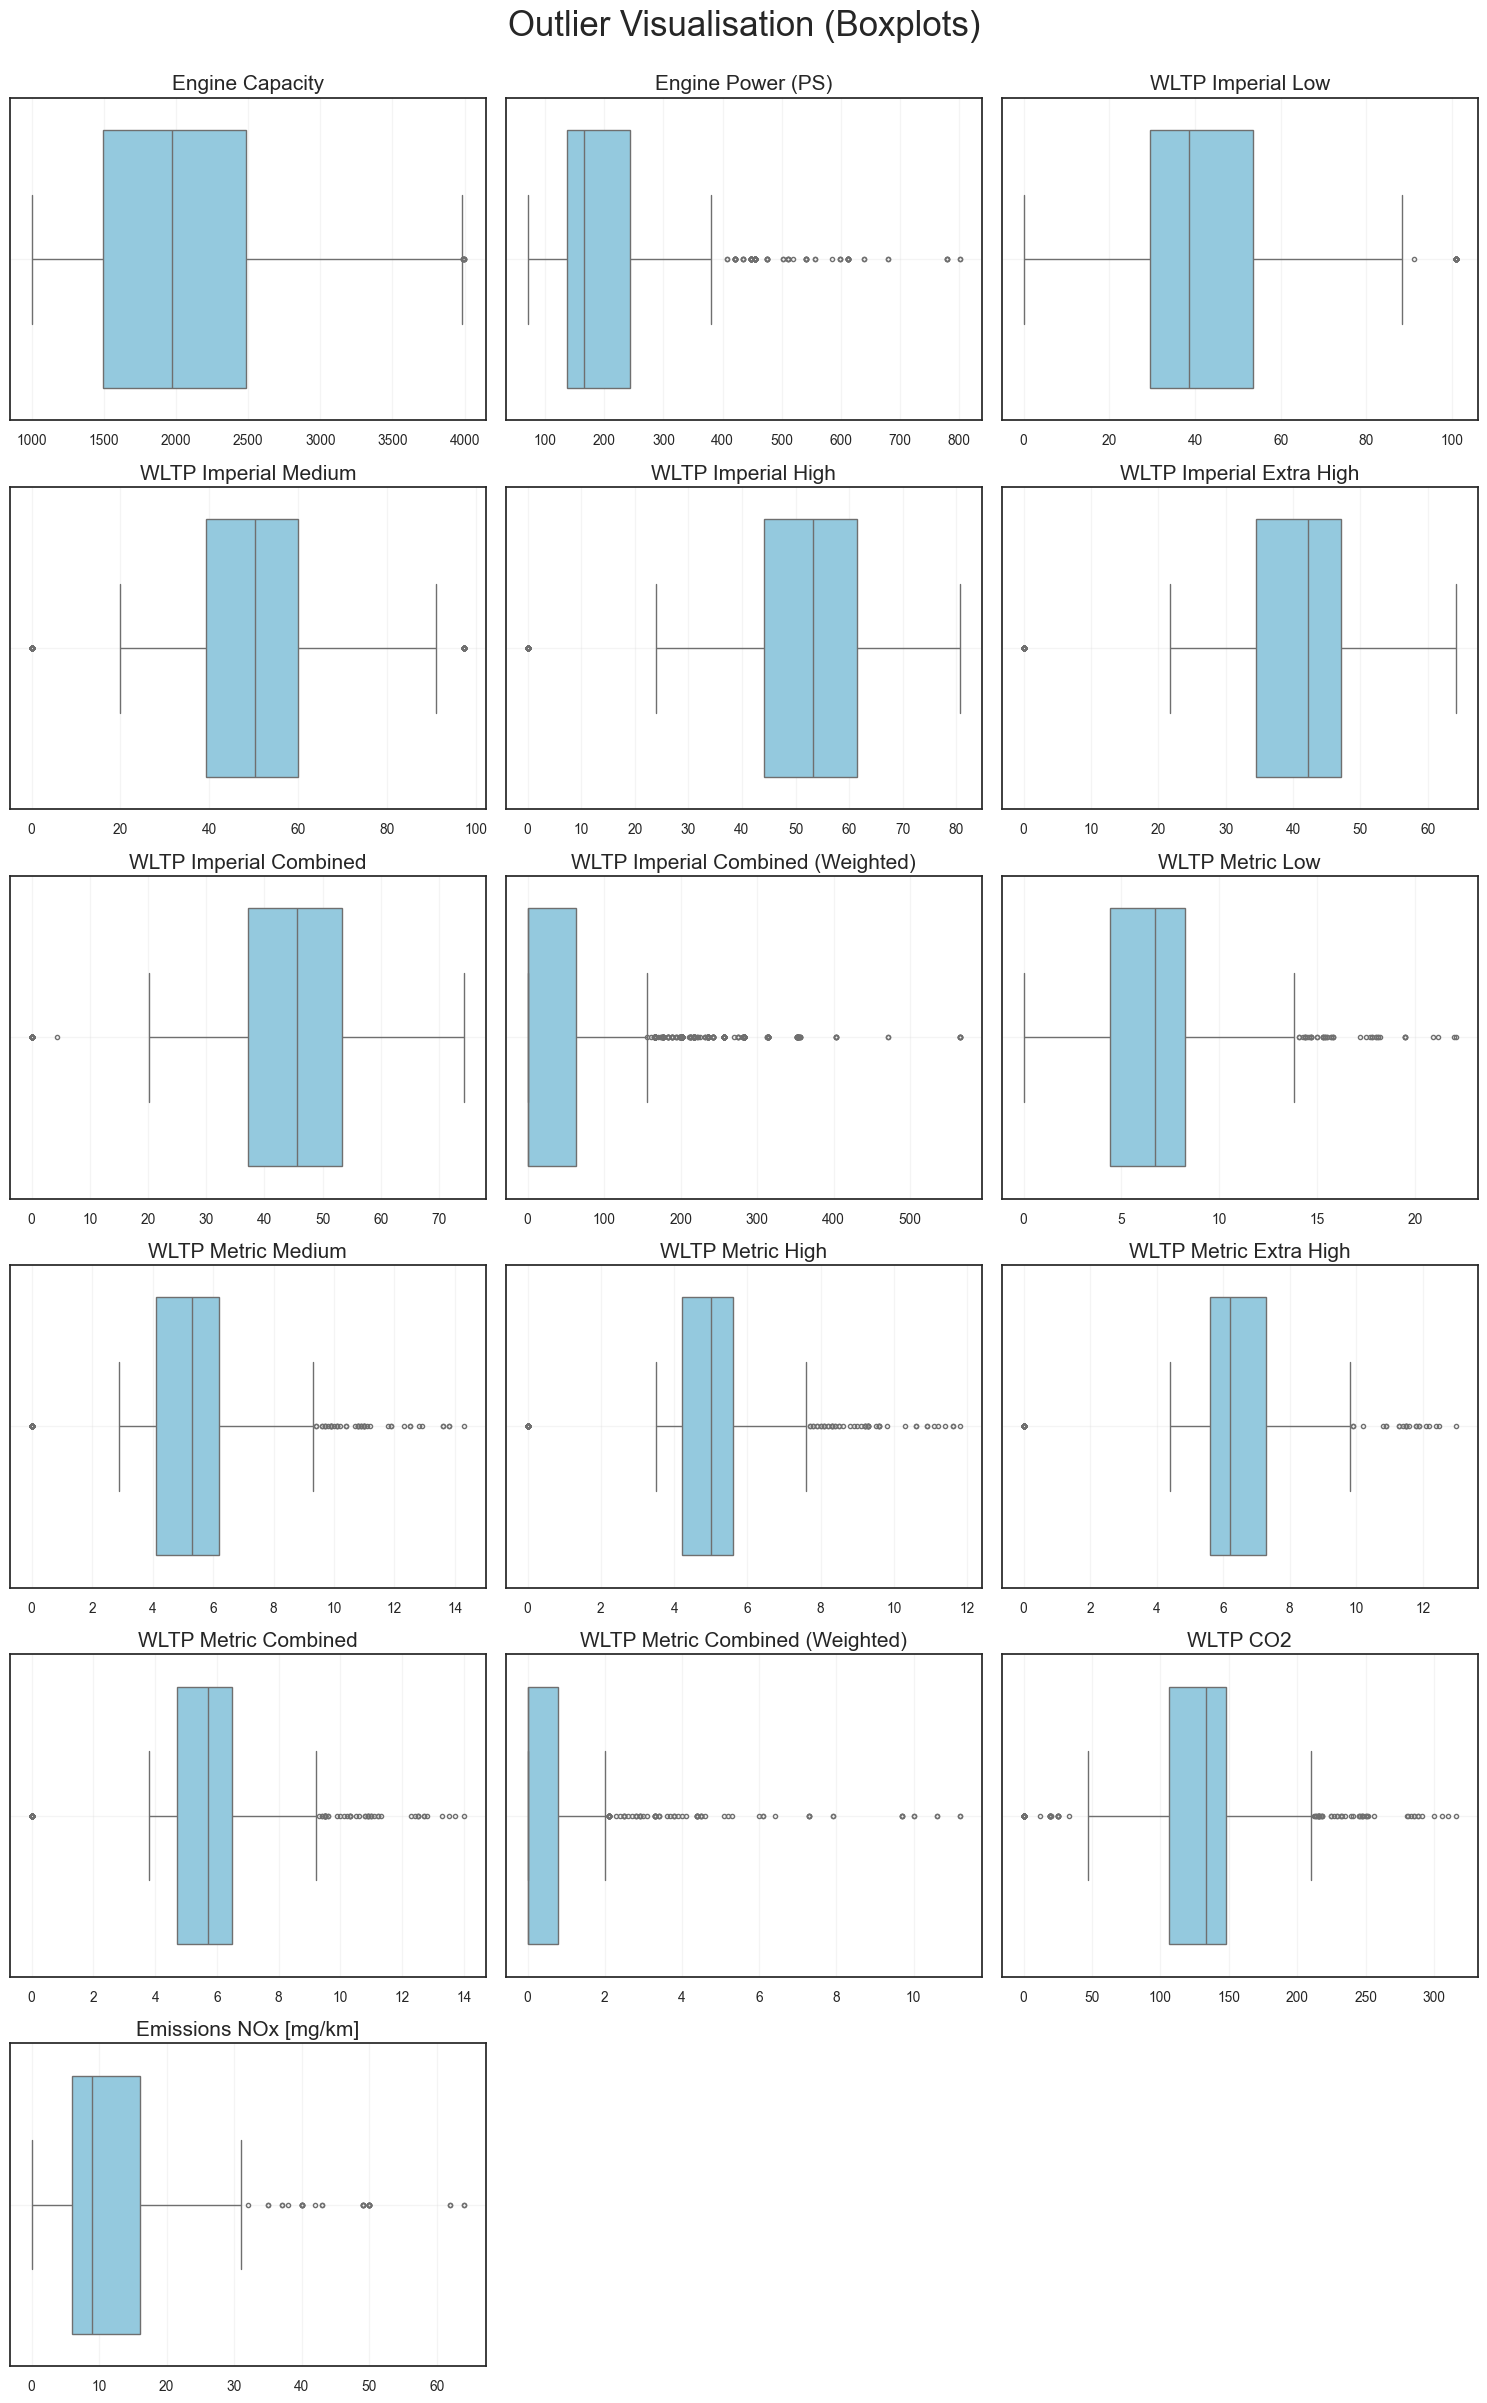

In [1073]:
outlier_check(data_hybrid)

The following variables should be removed from fuel car data since they have high amount of outliers: 

In [1074]:
removed_variables_hybrid = [ "WLTP Metric Low", "WLTP Metric Medium",
                            "WLTP Metric High", "WLTP Metric Extra High",
                            "WLTP Metric Combined", "WLTP Metric Combined (Weighted)",
                            "WLTP Imperial Combined (Weighted)" ]

print(f"Data shape before removing columns: {data_hybrid.shape}")

data_hybrid = data_hybrid.drop(columns=removed_variables_hybrid)
print(f"Data shape after removing columns: {data_hybrid.shape}")

Data shape before removing columns: (1683, 19)
Data shape after removing columns: (1683, 12)


Decide which variables to be removed for hybrid cars (comment here)

### The validation of datasets

In [1075]:
# Data Splitting Function into training set, test set, and validation set
np.random.seed(42) # for reproducibility

def data_split(target: str, data: pd.DataFrame, random_state: int = 42):
    assert target in data.columns, f"Target '{target}' not in dataframe."
    
    # Split X/y
    X = data.drop(columns=[target])
    y = data[target]
    
    # Simple numeric imputation (if there are any remaining NaNs)
    # X = X.fillna(X.mean(numeric_only=True)).fillna(0)
    
    # 80 / 20 split, then 10 / 10 from the 20
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, 
                                                         random_state=random_state)
    X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.50, 
                                                     random_state=random_state)
     
    # Encode categorical variables as dummy/one-hot columns
    X_train = pd.get_dummies(X_train, drop_first=True, dtype=float)
    X_val   = pd.get_dummies(X_val,   drop_first=True, dtype=float)
    X_test  = pd.get_dummies(X_test,  drop_first=True, dtype=float)

    #Re-index columns after encoding
    train_cols = X_train.columns
    X_val  = X_val.reindex(columns=train_cols, fill_value=0)
    X_test = X_test.reindex(columns=train_cols, fill_value=0)
    
    #Scaling the X data
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    return {
         "X_train": X_train,
         "X_val": X_val,
         "X_test": X_test,
         "y_train": y_train,
         "y_val": y_val,
         "y_test": y_test
    }     

#reuse this part to access the splitted data.
splits = data_split("WLTP CO2", data_fuel)

# Access the data 
X_train = splits["X_train"]
X_val   = splits["X_val"]
X_test  = splits["X_test"]
y_train = splits["y_train"]
y_val   = splits["y_val"]
y_test  = splits["y_test"]

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)
print(X_train[0:5,:])

(986, 13)
(124, 13)
(123, 13)
[[-0.69355105 -0.66468299  0.23878138  0.22261852  0.16192353  0.0135079
   0.15199583 -1.26703709 -0.96022252  0.5139091  -0.19466571  0.12428995
  -0.11558867]
 [ 3.44051473  3.98740879 -2.37420157 -2.1867223  -2.14748521 -2.05174708
  -2.26179734  0.2015991   1.04142527  0.5139091  -0.19466571  0.12428995
  -0.11558867]
 [-0.69355105 -0.50040367  0.59553551  0.43249142  0.31956235  0.087267
   0.29071957 -1.26703709  1.04142527  0.5139091  -0.19466571  0.12428995
  -0.11558867]
 [-0.20296869 -0.23158296 -0.03119472 -0.14675777 -0.18488188 -0.16562136
  -0.08845866 -1.26703709  1.04142527  0.5139091  -0.19466571  0.12428995
  -0.11558867]
 [-0.69453418 -0.81402783  1.51152584  1.47346097  1.34421469  0.86700613
   1.23404104 -0.62849962 -0.96022252  0.5139091  -0.19466571  0.12428995
  -0.11558867]]


*Fuel car data*


In [ ]:
# -- Reusable function for 10-fold CV and evaluation (regression task)--

np.random.seed(42) # for reproducibility

def tenfold_dataValidation(target: str, data: pd.DataFrame, random_state: int = 42):
    assert target in data.columns, f"Target '{target}' not in dataframe."

    #reuse this part to access the splitted data.
    splits = data_split(target, data)

    # Access the data 
    X_train = splits["X_train"]
    X_val   = splits["X_val"]
    X_test  = splits["X_test"]
    y_train = splits["y_train"]
    y_val   = splits["y_val"]
    y_test  = splits["y_test"]

    linear_model = LinearRegression()

    # 10-fold CV on TRAIN ONLY (neg MSE -> MSE) 
    mse_scores = -cross_val_score(linear_model, X_train, y_train, cv=10,
                              scoring="neg_mean_squared_error", n_jobs=-1)
    
    print("10-fold CV MSE scores:", mse_scores.tolist())
    print("Mean MSE:", np.mean(mse_scores))

    # Auto labeling based on Fuel Type column
    if data["Fuel Type"].isin(fuel_types).any():
        data_label = "Fuel Cars"
    elif data["Fuel Type"].isin(hybrid_types).any():
        data_label = "Hybrid Cars"
    else:
        data_label = "Dataset"

    # --- Plot CV MSE ---
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, 11), mse_scores, marker='o', linestyle='-')
    plt.title(f'10-Fold Cross-Validation (MSE) of {target} from {data_label}')
    plt.xlabel('Fold Number'); plt.ylabel('Mean Squared Error (MSE)')
    plt.grid(alpha=0.3); plt.xticks(range(1, 11))

    # --- Fit on train, check validation ---
    linear_model.fit(X_train, y_train)
    val_pred  = linear_model.predict(X_val)
    test_pred = linear_model.predict(X_test)

    # MSE on validation and test
    print("Validation MSE:", mean_squared_error(y_val,  val_pred))
    print("Test MSE:",       mean_squared_error(y_test, test_pred))
    print("\n") #spacing for readability

    # RMSE on validation and test
    print("Validation RMSE:", np.sqrt(mean_squared_error(y_val,  val_pred)))
    print("Test RMSE:",  np.sqrt(mean_squared_error(y_test, test_pred))) 

    # return splitted datasets for further use in NN function
    # return {
    # "X_train": X_train,
    # "X_val": X_val,
    # "X_test": X_test,
    # "y_train": y_train,
    # "y_val": y_val,
    # "y_test": y_test
    # }

<<<<<<< local


10-fold CV MSE scores: [226.8818560077228, 71.07971037711793, 240.4021221495773, 228.03641940795396, 185.59233512324136, 201.05651444852853, 392.8378576500156, 127.07826439321468, 237.20072334626278, 203.96008070823763]
Mean MSE: 211.41258836118723
Validation MSE: 936.3065519621466
Test MSE: 949.197496721195


Validation RMSE: 30.599126653585174
Test RMSE: 30.809048942172737


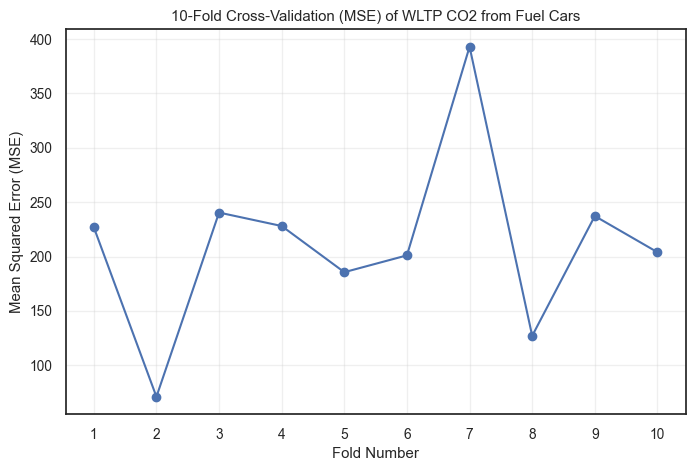

>>>>>>> remote


<<<<<<< local <removed>


10-fold CV MSE scores: [42.545850452272894, 181.2210006573705, 9735.125820094441, 91.34070680524069, 118.12145704286965, 32334.669826850615, 51.438675256912724, 136.7480169080796, 234.50314899532518, 105.95332234831741]
Mean MSE: 4303.166782541144
Validation MSE: 120.00489700599493
Test MSE: 37.50992515347082


Validation RMSE: 10.954674664543669
Test RMSE: 6.124534688731122


>>>>>>> remote <modified: >


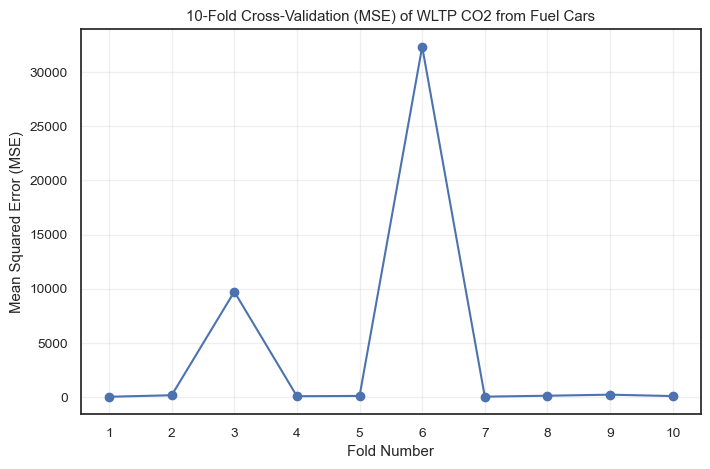

In [ ]:
# data validation for fuel cars, target variable: WLTP CO2
tenfold_dataValidation("WLTP CO2", data_fuel)

10-fold CV MSE scores: [196.263888695339, 166.97656776826773, 171.84763097495428, 236.30575475101722, 164.63380342084642, 171.42723437305426, 193.74103894193985, 585.9913886695763, 154.96234536980253, 197.3585544035697]
Mean MSE: 223.95082073683676
Validation MSE: 1400.8457844798568
Test MSE: 1293.3702178748638


Validation RMSE: 37.42787443176351
Test RMSE: 35.96345670086322


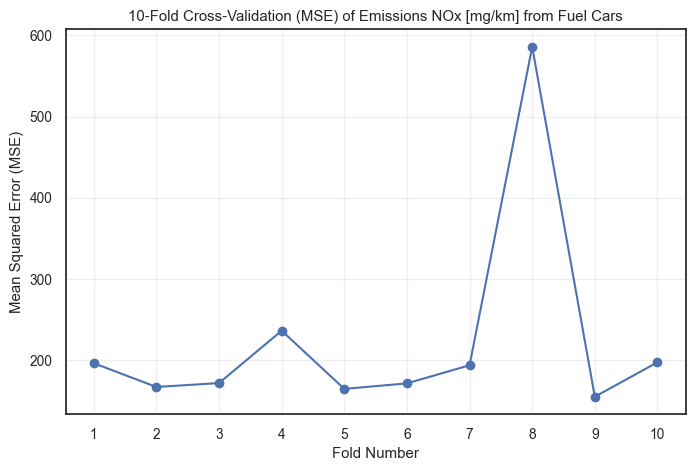

/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please als

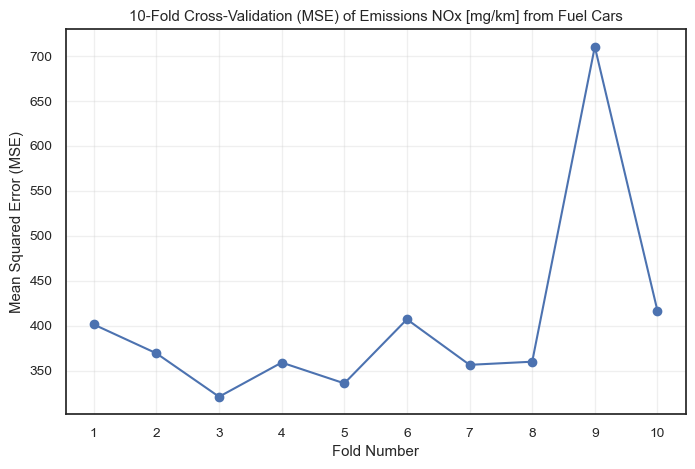

<<<<<<< local <removed>


/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


>>>>>>> remote <modified: >


In [ ]:
# data validation for fuel cars, target variable: Emissions NOx [mg/km]
tenfold_dataValidation("Emissions NOx [mg/km]", data_fuel)

*Hybrid car data*

<<<<<<< local


10-fold CV MSE scores: [1239.2532655144914, 1586.0682053838518, 1366.9974995948303, 1170.7755565874538, 1552.5254169525424, 1825.9652911355797, 1507.1878461500476, 1271.4742172473284, 970.3356191917294, 1391.3434076879907]
Mean MSE: 1388.1926325445847
Validation MSE: 1036.097747870503
Test MSE: 1539.993103265366


Validation RMSE: 32.18847228233274
Test RMSE: 39.242745868062876


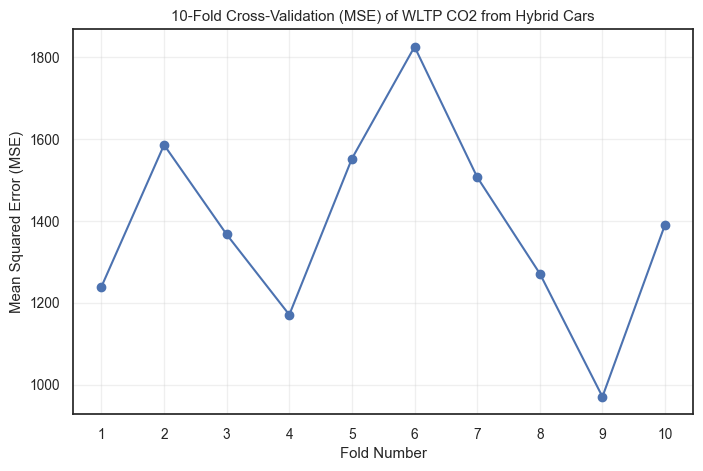

/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please als

>>>>>>> remote


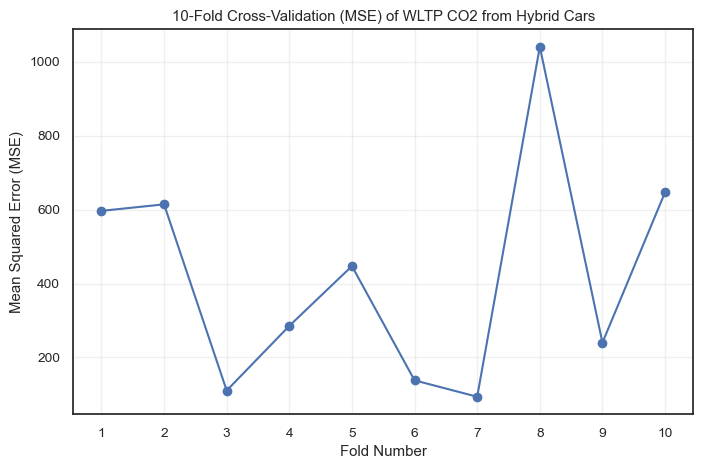

<<<<<<< local <removed>


/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


>>>>>>> remote <modified: >


In [ ]:
# data validation for hybrid cars, target variable: WLTP CO2
tenfold_dataValidation("WLTP CO2", data_hybrid)

<<<<<<< local


10-fold CV MSE scores: [42.27947119632712, 47.956806391015, 66.14828240354515, 57.94611387863636, 33.30093578990461, 42.873359949927355, 42.90273724034652, 36.751902710119815, 56.835284641779026, 39.163033607400436]
Mean MSE: 46.615792780900144
Validation MSE: 71.62983677331997
Test MSE: 24.3941498342779


Validation RMSE: 8.463441189806895
Test RMSE: 4.939043412876415


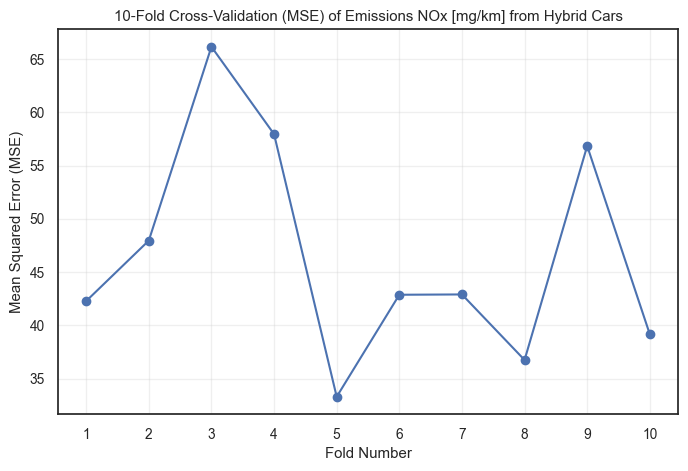

/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please als

>>>>>>> remote


<<<<<<< local <removed>


10-fold CV MSE scores: [42.65925925925926, 50.02962962962963, 55.49629629629629, 37.474074074074075, 61.67407407407408, 32.474074074074075, 63.559701492537314, 46.350746268656714, 44.014925373134325, 72.21641791044776]
Mean MSE: 50.59491984521835


>>>>>>> remote <unchanged>


/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please als

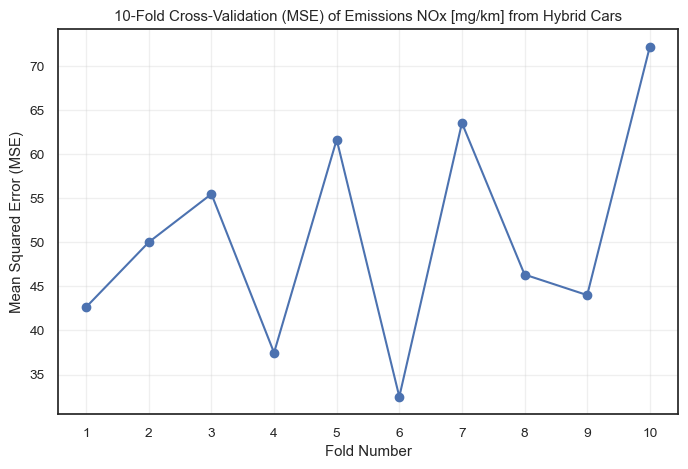

<<<<<<< local <removed>


/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


>>>>>>> remote <modified: >


In [ ]:
# data validation for hybrid cars, target variable: Emissions NOx [mg/km]
tenfold_dataValidation("Emissions NOx [mg/km]", data_hybrid)

In [182]:
def feature_select_lasso(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train,
    y_test,
    *,
    features: list | None = None,      # manually specify features; None = use all
    dataset_name: str = "Dataset",
    cv: int = 10,                      # 10-fold cross-validation
    random_state: int = 42,
    max_iter: int = 5000,
    lock_alpha: bool = False,          # set True to fix alpha instead of CV
    alpha_value: float | None = None,
    show_plots: bool = True
):
    """
    Lasso feature selection + 10-fold CV + overfitting checks + visualisations (RSS/MSE).
    Reuses existing train/test split.

    Returns
    -------
    results : dict         # metrics, alpha, selected transformed names, etc.
    pipeline : Pipeline    # fitted full pipeline (preprocessor + Lasso or LassoCV)
    """
    print(f"\n==================== {dataset_name.upper()} ====================")

    # --------------------- 1) Pick columns ----------------------
    if features is None:
        use_cols = X_train.columns.tolist()
    else:
        missing = [c for c in features if c not in X_train.columns]
        if missing:
            raise ValueError(f"Missing columns in X_train: {missing}")
        use_cols = list(dict.fromkeys(features))  # keep order, dedupe

    Xtr = X_train[use_cols].copy()
    Xte = X_test[use_cols].copy()

    # ------------------- 2) Preprocessing -----------------------
    numeric_cols = Xtr.select_dtypes(include=["float64", "int64"]).columns.tolist()
    cat_cols = [c for c in use_cols if c not in numeric_cols]  # dropped below

    numeric_pre = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler())
    ])
    pre = ColumnTransformer([
        ("num", numeric_pre, numeric_cols),
        ("cat", "drop", cat_cols)
    ])

    # ------------------- 3) Model (with CV) ---------------------
    if lock_alpha:
        if alpha_value is None:
            raise ValueError("lock_alpha=True requires alpha_value.")
        model = Lasso(alpha=alpha_value, random_state=random_state, max_iter=max_iter)
    else:
        model = LassoCV(cv=cv, random_state=random_state, max_iter=max_iter)

    pipe = Pipeline([("pre", pre), ("model", model)])

    # ------------------- 4) Fit & Predict -----------------------
    pipe.fit(Xtr, y_train)
    yhat_tr = pipe.predict(Xtr)
    yhat_te = pipe.predict(Xte)

    # ------------------- 5) Metrics (RSS + MSE) -----------------
    rss_train = float(np.sum((y_train - yhat_tr) ** 2))
    rss_test  = float(np.sum((y_test  - yhat_te) ** 2))
    mse_train = float(mean_squared_error(y_train, yhat_tr))
    mse_test  = float(mean_squared_error(y_test,  yhat_te))

    chosen_alpha = (alpha_value if lock_alpha else pipe.named_steps["model"].alpha_)
    print(f"Using features ({len(use_cols)}): {use_cols}")
    print(f"Alpha (λ): {chosen_alpha:.6f}")
    print(f"Train RSS: {rss_train:.2f} | Test RSS: {rss_test:.2f}")
    print(f"Train MSE: {mse_train:.2f} | Test MSE: {mse_test:.2f}")

    # ------------------- 6) Overfitting checks ------------------
    # Ratio & gap checks
    ratio = rss_test / rss_train if rss_train > 0 else np.inf
    gap_pct = (mse_test - mse_train) / mse_train * 100 if mse_train > 0 else np.inf

    status = "OK"
    if ratio > 2.0 or gap_pct > 50:   # simple, sensible thresholds
        status = "Possible overfit (test error >> train error)"
    elif ratio < 0.6 and gap_pct < -20:
        status = "Possible underfit/anomaly (train error >> test error)"

    print(f"Overfit check — RSS ratio (test/train): {ratio:.2f}, MSE gap: {gap_pct:.1f}% → {status}")

    # ------------------- 7) Visualisations ----------------------
    if show_plots:
        cols = 3 if (not lock_alpha) else 2
        fig, axes = plt.subplots(1, cols, figsize=(5*cols, 4))
        if cols == 2:
            ax_cv, ax_scatter, ax_coef = None, axes[0], axes[1]
        else:
            ax_cv, ax_scatter, ax_coef = axes[0], axes[1], axes[2]

        # (a) CV curve (only when using LassoCV)
        if not lock_alpha and hasattr(model, "mse_path_"):
            mean_path = model.mse_path_.mean(axis=1)
            ax_cv.semilogx(model.alphas_, mean_path, marker='.')
            ax_cv.axvline(model.alpha_, linestyle='--')
            ax_cv.set_title(f"CV MSE vs Alpha ({cv}-fold)")
            ax_cv.set_xlabel("Alpha (λ)")
            ax_cv.set_ylabel("Mean CV MSE")

        # (b) Predicted vs Actual (test)
        ax_scatter.scatter(y_test, yhat_te)
        lo, hi = float(np.min(y_test)), float(np.max(y_test))
        ax_scatter.plot([lo, hi], [lo, hi], linestyle='--')
        ax_scatter.set_title("Predicted vs Actual (Test)")
        ax_scatter.set_xlabel("Actual WLTP CO2")
        ax_scatter.set_ylabel("Predicted WLTP CO2")

        # (c) Coefficients
        coef = pipe.named_steps["model"].coef_
        names = pipe.named_steps["pre"].get_feature_names_out()
        ax_coef.barh(names, coef)
        ax_coef.set_title("Lasso Coefficients")
        ax_coef.set_xlabel("Coefficient")
        plt.tight_layout()
        plt.show()

    # ------------------- 8) Package results ---------------------
    selected_transformed = list(pipe.named_steps["pre"].get_feature_names_out())
    results = {
        "dataset": dataset_name,
        "features_requested": use_cols,
        "features_transformed": selected_transformed,   # after preprocessing
        "alpha": float(chosen_alpha),
        "rss_train": rss_train,
        "rss_test": rss_test,
        "mse_train": mse_train,
        "mse_test": mse_test,
        "rss_ratio_test_train": float(ratio),
        "mse_gap_pct": float(gap_pct),
        "overfit_flag": status,
        "cv": (cv if not lock_alpha else None)
    }
    return results, pipe


==================== FUEL (ALL) ====================
Using features (18): ['Engine Capacity', 'Engine Power (PS)', 'WLTP Imperial Low', 'WLTP Imperial Medium', 'WLTP Imperial High', 'WLTP Imperial Extra High', 'WLTP Imperial Combined', 'WLTP Metric Low', 'WLTP Metric Medium', 'WLTP Metric High', 'WLTP Metric Extra High', 'WLTP Metric Combined', 'Emissions NOx [mg/km]', 'Manual or Automatic_Manual', 'Fuel Type_Petrol', 'Fuel Type_Petrol / LPG', 'Powertrain_Internal Combustion Engine (ICE)', 'Powertrain_Micro Hybrid']
Alpha (λ): 2.581182
Train RSS: 162296.21 | Test RSS: 13947.90
Train MSE: 164.60 | Test MSE: 113.40
Overfit check — RSS ratio (test/train): 0.09, MSE gap: -31.1% → Possible underfit/anomaly (train error >> test error)


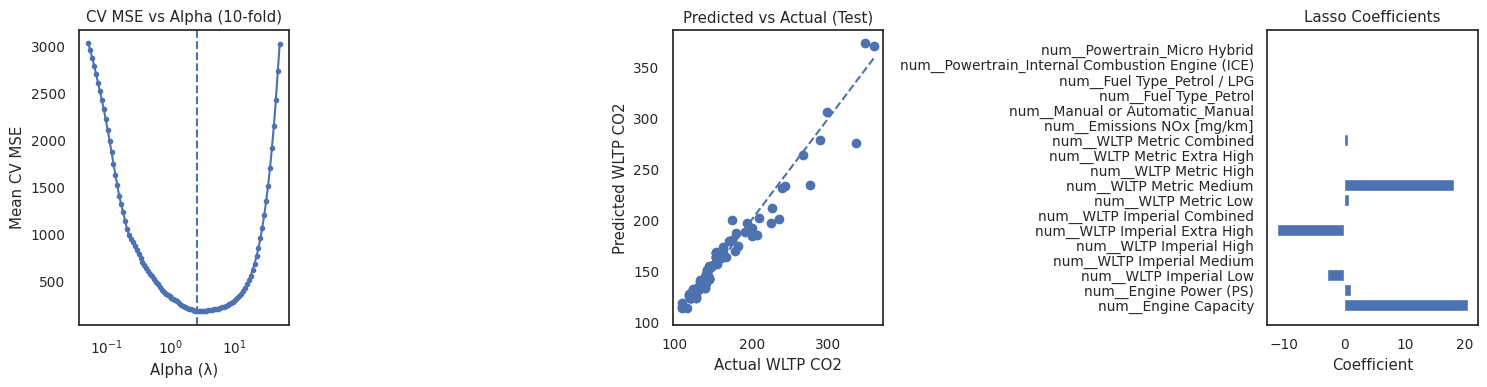

In [183]:
# Example 1 — Fuel: manually pick columns
(X_train, X_val, X_test, y_train, y_val, y_test) = [
    data_split("WLTP CO2", data_fuel)[k] for k in
    ["X_train", "X_val", "X_test", "y_train", "y_val", "y_test"]
]

res_fuel_manual, pipe_fuel_manual = feature_select_lasso(
    X_train, X_test, y_train, y_test,
    features=None,
    dataset_name="Fuel (All)",
    cv=10
)


==================== FUEL (LESS) ====================
Using features (3): ['Engine Capacity', 'Engine Power (PS)', 'WLTP Imperial Combined']
Alpha (λ): 0.142993
Train RSS: 215575.74 | Test RSS: 21753.71
Train MSE: 218.64 | Test MSE: 176.86
Overfit check — RSS ratio (test/train): 0.10, MSE gap: -19.1% → OK


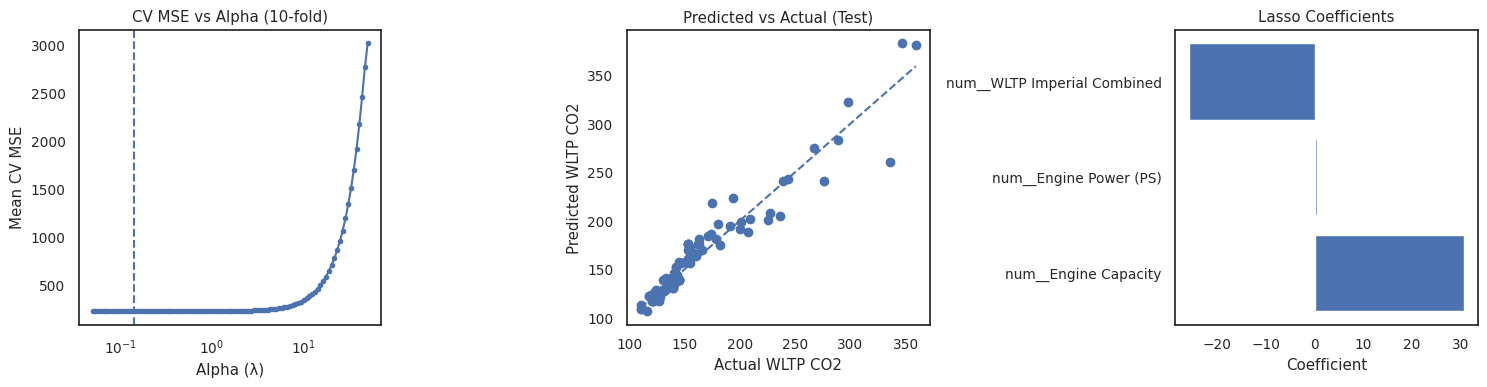

In [184]:
# Example 1 — Fuel: manually pick columns
(X_train, X_val, X_test, y_train, y_val, y_test) = [
    data_split("WLTP CO2", data_fuel)[k] for k in
    ["X_train", "X_val", "X_test", "y_train", "y_val", "y_test"]
]
fuel_feats = ['Engine Capacity', 'Engine Power (PS)','WLTP Imperial Combined']
res_fuel_manual, pipe_fuel_manual = feature_select_lasso(
    X_train, X_test, y_train, y_test,
    features=fuel_feats,
    dataset_name="Fuel (Less)",
    cv=10
)


==================== HYBRID (ALL) ====================
Using features (22): ['Engine Capacity', 'Engine Power (PS)', 'WLTP Imperial Low', 'WLTP Imperial Medium', 'WLTP Imperial High', 'WLTP Imperial Extra High', 'WLTP Imperial Combined', 'WLTP Imperial Combined (Weighted)', 'WLTP Metric Low', 'WLTP Metric Medium', 'WLTP Metric High', 'WLTP Metric Extra High', 'WLTP Metric Combined', 'WLTP Metric Combined (Weighted)', 'Emissions NOx [mg/km]', 'Manual or Automatic_Electric - Not Applicable', 'Manual or Automatic_Manual', 'Fuel Type_Electricity / Petrol', 'Fuel Type_Petrol Electric', 'Powertrain_Mild Hybrid Electric Vehicle (MHEV)', 'Powertrain_Plug-in Hybrid Electric Vehicle (PHEV)', 'Powertrain_Range Extended Electric Vehicle (REEV)']
Alpha (λ): 0.050881
Train RSS: 387105.72 | Test RSS: 39654.67
Train MSE: 287.60 | Test MSE: 236.04
Overfit check — RSS ratio (test/train): 0.10, MSE gap: -17.9% → OK


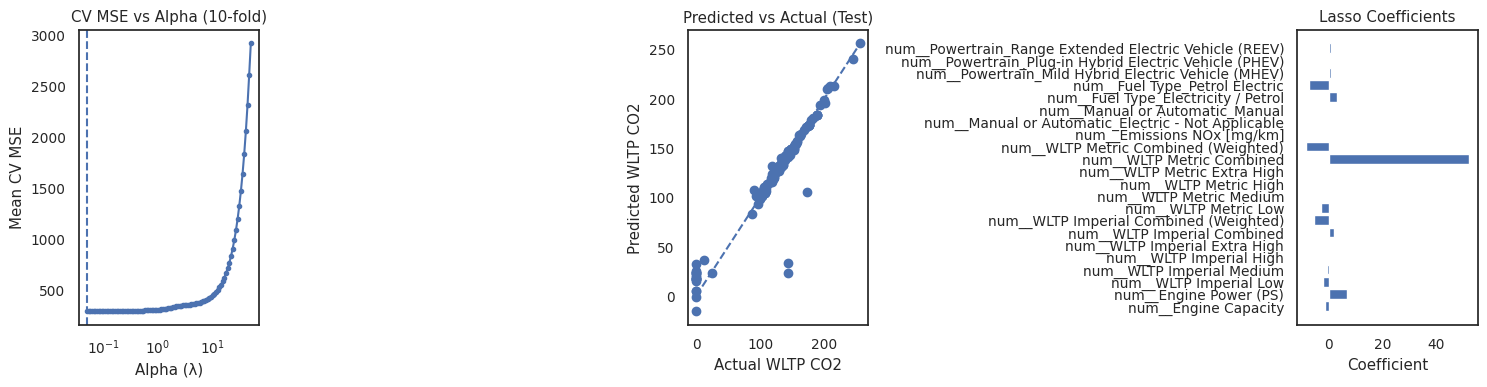

In [185]:
# Example 2 — Hybrid: use all columns (features=None)
(X_train, X_val, X_test, y_train, y_val, y_test) = [
    data_split("WLTP CO2", data_hybrid)[k] for k in
    ["X_train", "X_val", "X_test", "y_train", "y_val", "y_test"]
]

res_hybrid_all, pipe_hybrid_all = feature_select_lasso(
    X_train, X_test, y_train, y_test,
    features=None,
    dataset_name="Hybrid (all)",
    cv=10
)


==================== FUEL (LESS FEATURES) ====================
Using features (3): ['Engine Capacity', 'Engine Power (PS)', 'WLTP Imperial Combined']
Alpha (λ): 0.021702
Train RSS: 2788884.26 | Test RSS: 349599.31
Train MSE: 2071.98 | Test MSE: 2080.95
Overfit check — RSS ratio (test/train): 0.13, MSE gap: 0.4% → OK


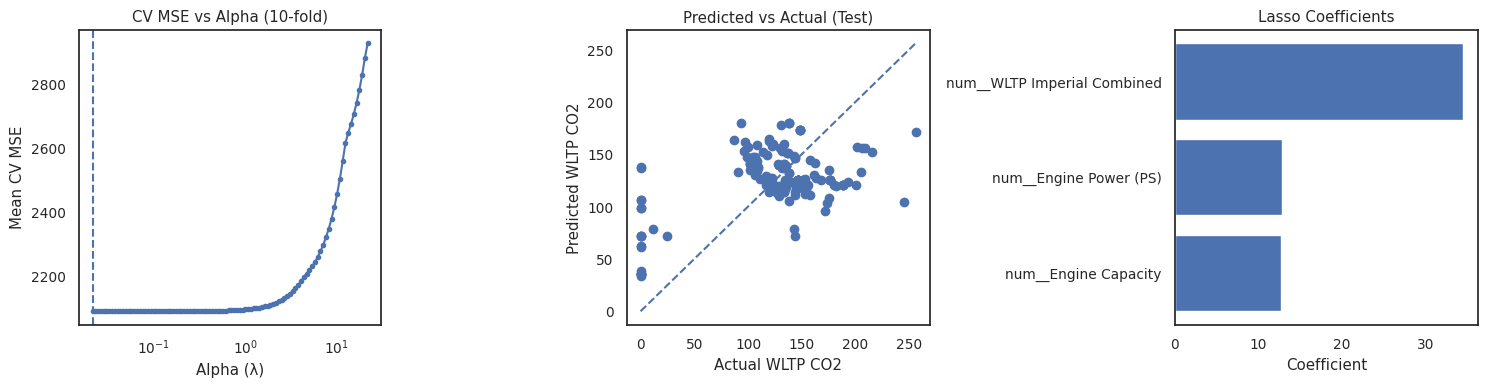

In [190]:
# Example 3 — Lock alpha to a known value (e.g., from a previous CV run)
(X_train, X_val, X_test, y_train, y_val, y_test) = [
    data_split("WLTP CO2", data_hybrid)[k] for k in
    ["X_train", "X_val", "X_test", "y_train", "y_val", "y_test"]
]

res_fuel_locked, pipe_fuel_locked = feature_select_lasso(
    X_train, X_test, y_train, y_test,
    features=fuel_feats,
    dataset_name="Fuel (less features)",
    cv=10
    #lock_alpha=True,
    #alpha_value=0.02
)

## Neural Network - Regression Tasks

**Variables Selection**
The following variables should be used to develop neural networks model.


In [ ]:
#print current variables from the fuel cars dataset
print(data_fuel.columns)
print(data_fuel.shape)

Index(['Manual or Automatic', 'Engine Capacity', 'Fuel Type', 'Powertrain',
       'Engine Power (PS)', 'WLTP Imperial Low', 'WLTP Imperial Medium',
       'WLTP Imperial High', 'WLTP Imperial Extra High',
       'WLTP Imperial Combined', 'WLTP CO2', 'Emissions NOx [mg/km]'],
      dtype='object')
(1233, 12)


### Neural Network Regression (2 Layers)

Training RMSE: 49.70696522807339
Coefficient of determination (R²) on training data: 0.1901
Test RMSE: 45.16897918744536
Coefficient of determination (R²) on test data: 0.0904
Validation RMSE: 53.23870459299605
Coefficient of determination (R²) on  validation data: 0.2213


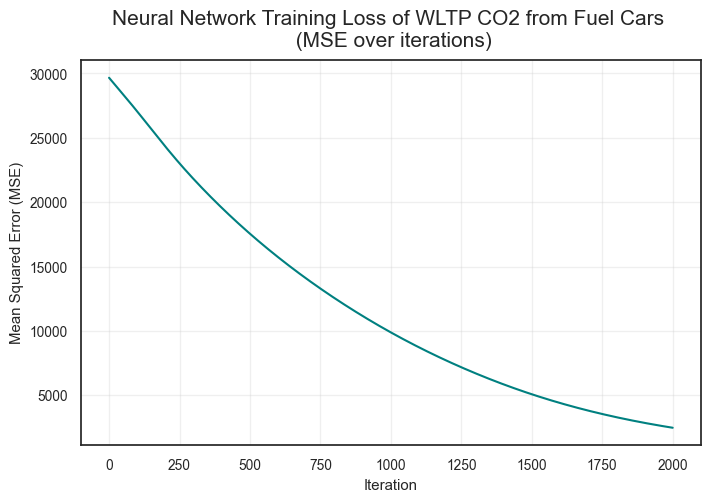

In [ ]:
# Reusable function for Neural Network regression task - simple 1 hidden layer NN
def neural_network_regression(target: str, data: pd.DataFrame, random_state: int = 42):
    assert target in data.columns, f"Target '{target}' not in dataframe."

    # Split X/y
    X = data.drop(columns=[target])
    y = data[target]

    features = X.columns.tolist()
    
    # Encode categorical variables as dummy/one-hot columns
    X = pd.get_dummies(X, drop_first=True, dtype=float)

    # Simple numeric imputation (if there are any remaining NaNs)
    X = X.fillna(X.mean(numeric_only=True)).fillna(0)
    X = X.dropna(axis=0, how='any')  # drop any columns that still have NaNs after mean imputation

    y = y.fillna(y.mean())
    y = y.dropna()

    # reshape y into a 2D array
    y = y.values.reshape(-1, 1)

    # 80 / 20 split, then 10 / 10 from the 20
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, 
                                                        random_state=random_state)
    X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.50, 
                                                    random_state=random_state)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    X_val_scaled = scaler.transform(X_val)

    # Define NN dimensions
    N = len(y_train) # number of samples
    D_in = X_train_scaled.shape[1] # number of features: 17
    D_out = 1 # number of outputs
    H = 20 # number of hidden neurons, based on number of features

    # Initialize weights
    W0 = normal(0, 0.1, size=(D_in, H))
    W1 = normal(0, 0.1, size=(H, D_out))

    # Training loop
    eta = 0.00005

    loss_history = []
    for i in range(2001):
        # forward pass
        
        ## Bias Terms
        b0 = np.zeros((1, H))
        b1 = np.zeros((1, 1))
        # z1 = X.dot(W0) + b0
        # a2 = a1.dot(W1) + b1

        z1 = X_train_scaled.dot(W0) + b0
        z1 = np.clip(z1, -500, 500)
        a1 = 1 / (1 + np.exp(-z1))
        a2 = a1.dot(W1) + b1
        Loss = np.mean((a2 - y_train) ** 2)
        loss_history.append(Loss)

        # # print loss every 100 iterations
        # if i % 100 == 0:
        #     print(f"Iteration {i}: Loss {Loss:.4f}")
    
        # backward pass
        da2 = 2.0 * (a2 - y_train)
        dW1 = a1.T.dot(da2) / N
        da1 = da2.dot(W1.T)
        dz1 = da1 * a1 * (1 - a1)
        dW0 = X_train_scaled.T.dot(dz1) / N
        
        # update
        W0 -= eta * dW0 # weights update for features
        W1 -= eta * dW1

    # Evaluate
    z1 = X_train_scaled.dot(W0)
    z1 = np.clip(z1, -500, 500)
    a1 = 1 / (1 + np.exp(-z1))
    y_pred = a1.dot(W1)

    # MSE and RMSE on training data
    print('Training RMSE:', np.sqrt(mean_squared_error(y_train, y_pred)))
    print('Coefficient of determination (R²) on training data:', round(r2_score(y_train, y_pred),4))

    # Evaluate on test set
    z1 = X_test_scaled.dot(W0)
    z1 = np.clip(z1, -500, 500)
    a1 = 1 / (1 + np.exp(-z1))
    y_test_pred = a1.dot(W1)

    print('Test RMSE:', np.sqrt(mean_squared_error(y_test, y_test_pred)))
    print('Coefficient of determination (R²) on test data:', round(r2_score(y_test, y_test_pred),4))

    # Evaluate on validation set
    z1 = X_val_scaled.dot(W0)
    z1 = np.clip(z1, -500, 500)
    a1 = 1 / (1 + np.exp(-z1))
    y_val_pred = a1.dot(W1)
    print('Validation RMSE:', np.sqrt(mean_squared_error(y_val, y_val_pred)))
    print('Coefficient of determination (R²) on  validation data:', round(r2_score(y_val, y_val_pred),4))


    # Auto labeling based on Fuel Type column
    if data["Fuel Type"].isin(fuel_types).any():
        data_label = "Fuel Cars"
    elif data["Fuel Type"].isin(hybrid_types).any():
        data_label = "Hybrid Cars"
    else:
        data_label = "Dataset"


    #Visualise the MSE
    plt.figure(figsize=(8,5))
    plt.plot(loss_history, color='teal')
    plt.title(f"Neural Network Training Loss of {target} from {data_label} \n (MSE over iterations)",
              fontsize = 15, pad = 10)
    plt.xlabel("Iteration")
    plt.ylabel("Mean Squared Error (MSE)")
    plt.grid(alpha=0.3)
    plt.show()

    # # Return the weights and features of the model
    # return{
    #     "features": features,
    #     "W0": W0
    #     }

# Neural Network regression for fuel cars, target variable: WLTP CO2
neural_network_regression("WLTP CO2", data_fuel)

Training RMSE: 17.03577936325616
Coefficient of determination (R²) on training data: -0.1833
Test RMSE: 13.197758359138767
Coefficient of determination (R²) on test data: -0.1638
Validation RMSE: 14.601247944046428
Coefficient of determination (R²) on  validation data: -0.2495


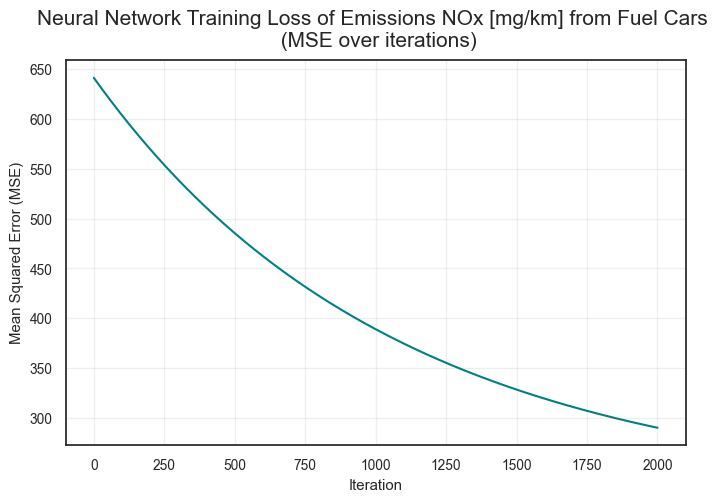

In [ ]:
# Neural Network regression for fuel cars, target variable: Emissions NOx [mg/km]
neural_network_regression("Emissions NOx [mg/km]", data_fuel)

Training RMSE: 63.48374376536428
Coefficient of determination (R²) on training data: -0.3744
Test RMSE: 62.02876237884712
Coefficient of determination (R²) on test data: -0.3851
Validation RMSE: 56.44461607999293
Coefficient of determination (R²) on  validation data: -0.5741


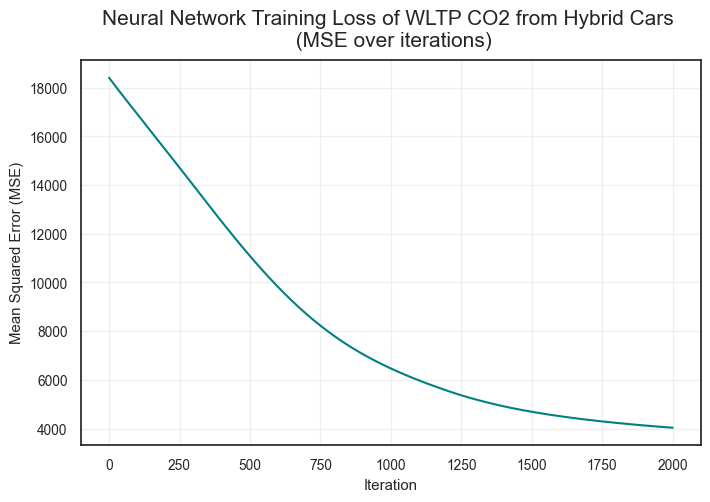

In [ ]:
# Neural Network regression for hybrid cars, target variable: WLTP CO2
neural_network_regression("WLTP CO2", data_hybrid)

Training RMSE: 9.15832712739501
Coefficient of determination (R²) on training data: -0.1143
Test RMSE: 6.878153593098071
Coefficient of determination (R²) on test data: -0.0491
Validation RMSE: 10.690599109433597
Coefficient of determination (R²) on  validation data: -0.1485


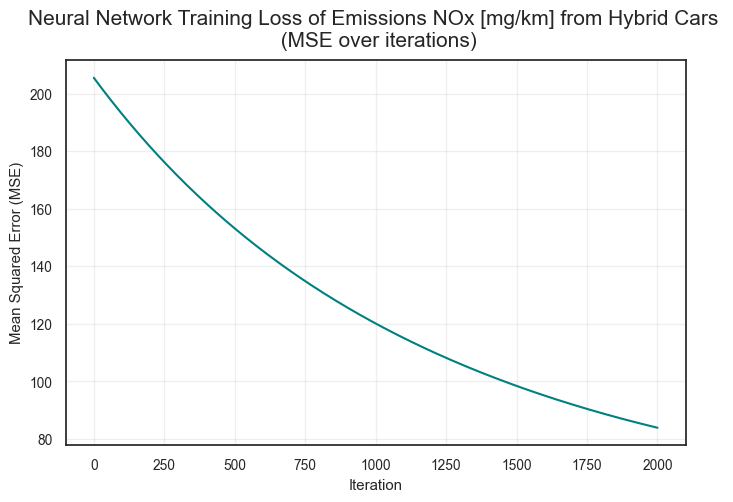

In [ ]:
# Neural Network regression for hybrid cars, target variable: Emissions NOx [mg/km]
neural_network_regression("Emissions NOx [mg/km]", data_hybrid)

In [ ]:
# #Examine weights from the NNR
# import io, contextlib

# buf = io.StringIO()
# with contextlib.redirect_stdout(buf):  # hide print outputs
#     res = neural_network_regression("WLTP CO2", data_fuel);

# # from your Regressor() output
# W0 = res["W0"]                    # shape: [n_features, H]
# features = res["features"]
# imp = np.mean(np.abs(W0), axis=1)

# print("W0 shape:", W0.shape)
# print("Number of features:", len(features))

# # Ensure they match in length
# min_len = min(len(features), len(imp))
# features = features[:min_len]
# imp = imp[:min_len]

# imp_df = pd.DataFrame({"Feature": features, "Importance": imp})
# imp_df = imp_df.sort_values(by="Importance", ascending=True)



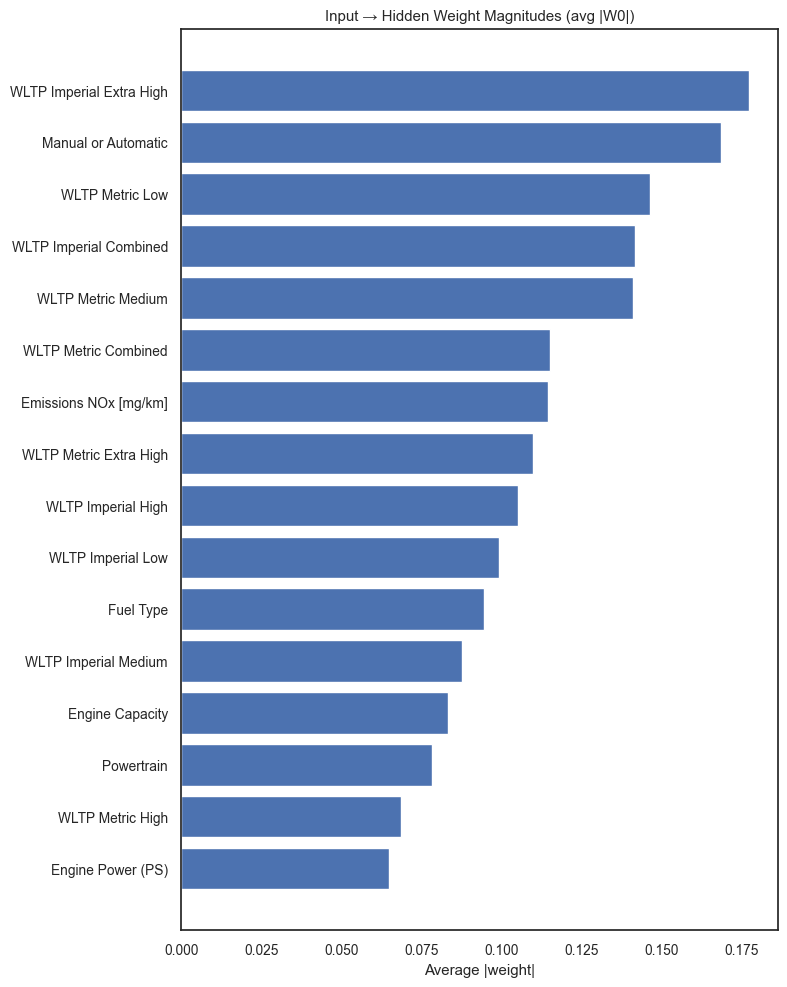

In [1088]:
# importance = average absolute incoming weight to hidden layer
plt.figure(figsize=(8, 10))
plt.barh(imp_df["Feature"], imp_df["Importance"])
plt.title("Input → Hidden Weight Magnitudes (avg |W0|)")
plt.xlabel("Average |weight|")
plt.tight_layout()
plt.show()

### Neural Network Regression - 3 Layers

Training RMSE: 48.299070650123596
Coefficient of determination (R²) on training data: 0.2353
Test RMSE: 39.93733534536793
Coefficient of determination (R²) on test data: 0.2889
Validation RMSE: 53.696779563332164
Coefficient of determination (R²) on  validation data: 0.2079


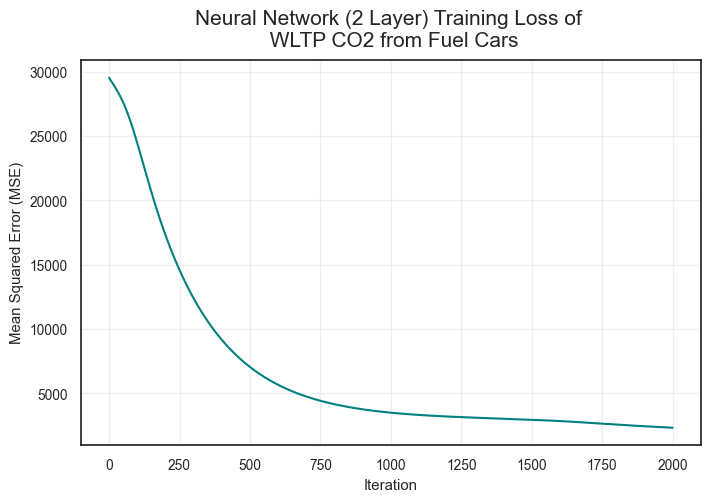

In [1089]:
# Reusable function for Neural Network regression task - 2 hidden layer NN
def neural_network_regression_2hidden(target: str, data: pd.DataFrame, random_state: int = 42):
    assert target in data.columns, f"Target '{target}' not in dataframe."

    splits = data_split(target, data)

    X_train = splits["X_train"]
    X_val   = splits["X_val"]
    X_test  = splits["X_test"]
    y_train = splits["y_train"]   
    y_val   = splits["y_val"]
    y_test  = splits["y_test"]      

    # Flatten target arrays
    y_train = y_train.values.reshape(-1, 1)
    y_val   = y_val.values.reshape(-1, 1)
    y_test  = y_test.values.reshape(-1, 1)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    X_val_scaled = scaler.transform(X_val)

    # Define NN dimensions
    N = len(y_train) # number of samples
    D_in = X_train_scaled.shape[1] # number of features
    D_out = 1 # number of outputs
    H1 = 30 # number of hidden neurons in hidden layer 1
    H2 = 20 # number of hidden neurons in hidden layer 2

    # -- Initialize weights
    # Layer 1: input -> hidden1
    W0 = normal(0, 0.1, size=(D_in, H1))
    b0 = np.zeros((1, H1))

    # Layer 2: hidden1 -> hidden2
    W1 = normal(0, 0.1, size=(H1, H2))
    b1 = np.zeros((1, H2))

    # Output: hidden2 -> output
    W2 = normal(0, 0.1, size=(H2, D_out))
    b2 = np.zeros((1, D_out))
    
    # Training loop
    eta = 0.00005

    loss_history = []
    for i in range(2001):
        # ---- forward pass ----
        ## Layer 1
        z1 = X_train_scaled.dot(W0) + b0
        z1 = np.clip(z1, -500, 500) 
        a1 = 1.0 / (1.0 + np.exp(-z1)) # sigmoid

        # Layer 2
        z2 = a1.dot(W1) + b1
        z2 = np.clip(z2, -500, 500)
        a2 = 1.0 / (1.0 + np.exp(-z2)) # sigmoid

        # Output (linear)
        y_hat = a2.dot(W2) + b2

        # Loss (MSE)
        Loss = np.mean((y_hat - y_train) ** 2)
        loss_history.append(float(Loss))

        # ---- backward pass ----
        # dLoss/dy_hat = 2*(y_hat - y) / N
        dy = (2.0 / N) * (y_hat - y_train)

        # Gradients for output layer (a2 -> y_hat)
        dW2 = a2.T.dot(dy)     
        db2 = np.sum(dy, axis=0, keepdims=True) 

        # Backprop into hidden2
        da2 = dy.dot(W2.T)                        
        dz2 = da2 * a2 * (1.0 - a2)               
        dW1 = a1.T.dot(dz2)                       
        db1 = np.sum(dz2, axis=0, keepdims=True)  

        # Backprop into hidden1
        da1 = dz2.dot(W1.T)                       
        dz1 = da1 * a1 * (1.0 - a1)               
        dW0 = X_train_scaled.T.dot(dz1)           
        db0 = np.sum(dz1, axis=0, keepdims=True) 

        # ---- update parameters ----
        W2 -= eta * dW2
        b2 -= eta * db2
        W1 -= eta * dW1
        b1 -= eta * db1
        W0 -= eta * dW0
        b0 -= eta * db0

    # # Evaluate
    # z1 = X_train_scaled.dot(W0)
    # z1 = np.clip(z1, -500, 500)
    # a1 = 1 / (1 + np.exp(-z1))
    # y_pred = a1.dot(W2)

    # Evaluate on training set
    z1_ = X_train_scaled.dot(W0) + b0
    z1_ = np.clip(z1_, -500, 500)
    a1_ = 1.0 / (1.0 + np.exp(-z1_))
    
    z2_ = a1_.dot(W1) + b1
    z2_ = np.clip(z2_, -500, 500)
    a2_ = 1.0 / (1.0 + np.exp(-z2_))
    
    y_pred = a2_.dot(W2) + b2

    # MSE and RMSE on training data
    print('Training RMSE:', np.sqrt(mean_squared_error(y_train, y_pred)))
    print('Coefficient of determination (R²) on training data:', round(r2_score(y_train, y_pred),4))

    # Evaluate on test set
    z1_ = X_test_scaled.dot(W0) + b0
    z1_ = np.clip(z1_, -500, 500)
    a1_ = 1.0 / (1.0 + np.exp(-z1_))
    z2_ = a1_.dot(W1) + b1
    z2_ = np.clip(z2_, -500, 500)
    a2_ = 1.0 / (1.0 + np.exp(-z2_))
    y_test_pred = a2_.dot(W2) + b2

    print('Test RMSE:', np.sqrt(mean_squared_error(y_test, y_test_pred)))
    print('Coefficient of determination (R²) on test data:', round(r2_score(y_test, y_test_pred),4))

    # Evaluate on validation set
    z1_ = X_val_scaled.dot(W0) + b0
    z1_ = np.clip(z1_, -500, 500)
    a1_ = 1.0 / (1.0 + np.exp(-z1_))
    z2_ = a1_.dot(W1) + b1
    z2_ = np.clip(z2_, -500, 500)
    a2_ = 1.0 / (1.0 + np.exp(-z2_))
    y_val_pred = a2_.dot(W2) + b2
    
    print('Validation RMSE:', np.sqrt(mean_squared_error(y_val, y_val_pred)))
    print('Coefficient of determination (R²) on  validation data:', round(r2_score(y_val, y_val_pred),4))


    # Auto labeling based on Fuel Type column
    if data["Fuel Type"].isin(fuel_types).any():
        data_label = "Fuel Cars"
    elif data["Fuel Type"].isin(hybrid_types).any():
        data_label = "Hybrid Cars"
    else:
        data_label = "Dataset"


    #Visualise the MSE
    plt.figure(figsize=(8,5))
    plt.plot(loss_history, color='teal')
    plt.title(f"Neural Network (2 Layer) Training Loss of \n {target} from {data_label}",
              fontsize = 15, pad = 10)
    plt.xlabel("Iteration")
    plt.ylabel("Mean Squared Error (MSE)")
    plt.grid(alpha=0.3)
    plt.show()

    # # Return the weights and features of the model
    # return{
    #     "features": features,
    #     "W0": W0
    #     }

# Neural Network regression for fuel cars, target variable: WLTP CO2
neural_network_regression_2hidden("WLTP CO2", data_fuel)

Training RMSE: 48.53711854086359
Coefficient of determination (R²) on training data: 0.2278
Test RMSE: 43.932947462620355
Coefficient of determination (R²) on test data: 0.1395
Validation RMSE: 52.44519221370094
Coefficient of determination (R²) on  validation data: 0.2444


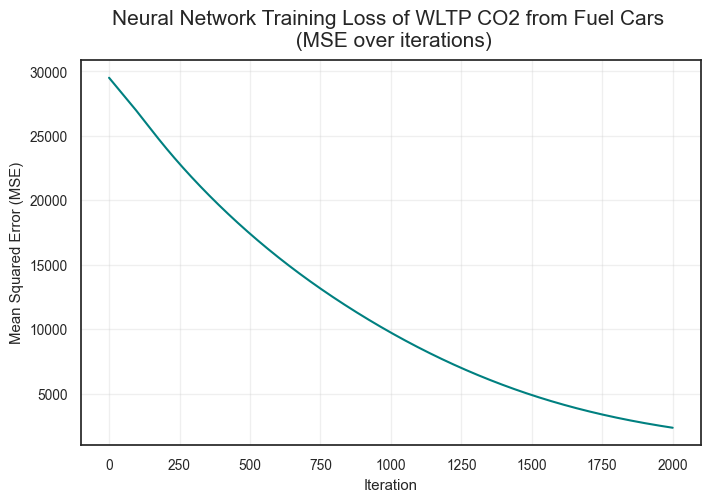

Training RMSE: 48.20495575471616
Coefficient of determination (R²) on training data: 0.2383
Test RMSE: 39.524078957456695
Coefficient of determination (R²) on test data: 0.3036
Validation RMSE: 53.38844724964508
Coefficient of determination (R²) on  validation data: 0.2169


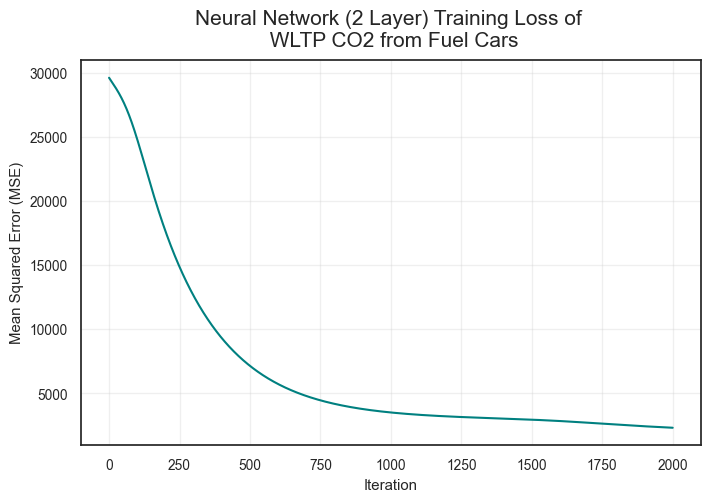

In [1090]:
# -- Evaluation of neural network model based on numbers of layers --
neural_network_regression("WLTP CO2", data_fuel)
neural_network_regression_2hidden("WLTP CO2", data_fuel)

### Neural Network Regression - 4 Layers

In [1091]:
# Reusable function for Neural Network regression task - 3 hidden layer NN

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def neural_network_regression_3hidden(target: str, data: pd.DataFrame, random_state: int = 42):
    assert target in data.columns, f"Target '{target}' not in dataframe."

    # Perform data splitting
    splits = data_split(target, data)   
    
    X_train = splits["X_train"]
    X_val   = splits["X_val"]
    X_test  = splits["X_test"]
    y_train = splits["y_train"]   
    y_val   = splits["y_val"]
    y_test  = splits["y_test"]
    
    # Flatten target arrays
    y_train = y_train.values.reshape(-1, 1)
    y_val   = y_val.values.reshape(-1, 1)
    y_test  = y_test.values.reshape(-1, 1)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    X_val_scaled = scaler.transform(X_val)

    # Define NN dimensions
    N = len(y_train) # number of samples
    D_in = X_train_scaled.shape[1] # number of features
    D_out = 1 # number of outputs
    
    H1 = 40 # number of hidden neurons in hidden layer 1
    H2 = 30 # number of hidden neurons in hidden layer 2
    H3 = 20 # number of hidden neurons in hidden layer 3

    # -- Initialize weights
    # Layer 1: input -> hidden1
    W0 = normal(0, 0.1, size=(D_in, H1))
    b0 = np.zeros((1, H1))

    # Layer 2: hidden1 -> hidden2
    W1 = normal(0, 0.1, size=(H1, H2))
    b1 = np.zeros((1, H2))

    # Layer 3: hidden2 -> hidden3
    W2 = normal(0, 0.1, size=(H2, H3))
    b2 = np.zeros((1, H3))

    # Output: hidden3 -> output
    W3 = normal(0, 0.1, size=(H3, D_out))
    b3 = np.zeros((1, D_out))
    
    # Training loop
    eta = 0.00005

    loss_history = []
    for i in range(2001):
        # ---- forward pass ----
        ## Layer 1
        z1 = X_train_scaled.dot(W0) + b0
        z1 = np.clip(z1, -500, 500) 
        a1 = 1 / (1 + np.exp(-z1)) # sigmoid

        # Layer 2
        z2 = a1.dot(W1) + b1
        z2 = np.clip(z2, -500, 500)
        a2 = 1 / (1 + np.exp(-z2)) # sigmoid

        # Layer 3
        z3 = a2.dot(W2) + b2
        z3 = np.clip(z3, -500, 500)
        a3 = 1 / (1 + np.exp(-z3)) # sigmoid

        # Output (linear)
        y_hat = a3.dot(W3) + b3

        # Loss (MSE)
        Loss = np.mean((y_hat - y_train) ** 2)
        loss_history.append(float(Loss))


        # ---- backward pass ----
        N  = len(y_train)
        dy = (2.0 / N) * (y_hat - y_train)

        # Gradients for output layer (a3 -> y_hat)
        dW3 = a3.T.dot(dy)       
        db3 = np.sum(dy, axis=0, keepdims=True)

        # Backprop into hidden3
        da3 = dy.dot(W3.T)
        dz3 = da3 * a3 * (1 - a3)
        dW2 = a2.T.dot(dz3)
        db2 = np.sum(dz3, axis=0, keepdims=True)
        
        # Backprop into hidden2
        da2 = dz3.dot(W2.T)
        dz2 = da2 * a2 * (1 - a2)
        dW1 = a1.T.dot(dz2)
        db1 = np.sum(dz2, axis=0, keepdims=True)
        
        # Backprop into hidden1
        da1 = dz2.dot(W1.T)
        dz1 = da1 * a1 * (1 - a1)
        dW0 = X_train_scaled.T.dot(dz1)
        db0 = np.sum(dz1, axis=0, keepdims=True)
 
        # ---- update parameters ----
        W3 -= eta * dW3
        b3 -= eta * db3
        W2 -= eta * dW2
        b2 -= eta * db2
        W1 -= eta * dW1
        b1 -= eta * db1
        W0 -= eta * dW0
        b0 -= eta * db0

    # Evaluate on training set
            # def predict(X_scaled):
            #     z1 = X_scaled.dot(W0) + b0
            #     z1_ = np.clip(z1, -500, 500)
            #     a1 = 1.0 / (1.0 + np.exp(-z1_))
                
            #     z2 = a1.dot(W1) + b1
            #     z2_ = np.clip(z2, -500, 500)
            #     a2 = np.clip(z2_, -500, 500)
                
            #     z3 = a2.dot(W2) + b2
            #     z3_ = np.clip(z3, -500, 500)
            #     a3 = 1.0 / (1.0 + np.exp(-z3_))

            #     return a3.dot(W3) + b3

    # MSE and RMSE on training data
    z1 = X_train_scaled.dot(W0) + b0
    z1_ = np.clip(z1, -500, 500)
    a1 = 1.0 / (1.0 + np.exp(-z1_))
        
    z2 = a1.dot(W1) + b1
    z2_ = np.clip(z2, -500, 500)
    a2 = np.clip(z2_, -500, 500)
    
    z3 = a2.dot(W2) + b2
    z3_ = np.clip(z3, -500, 500)
    a3 = 1.0 / (1.0 + np.exp(-z3_))
    y_train_pred = a3.dot(W3) + b3

    print('Training RMSE:', np.sqrt(mean_squared_error(y_train, y_train_pred)))
    print('Coefficient of determination (R²) on training data:', round(r2_score(y_train, y_train_pred),4))

    # Evaluate on test set
    y_test_pred = predict(X_test_scaled)
    print('Test RMSE:', np.sqrt(mean_squared_error(y_test, y_test_pred)))
    print('Coefficient of determination (R²) on test data:', round(r2_score(y_test, y_test_pred),4))

    # Evaluate on validation set
    y_val_pred = predict(X_val_scaled)
    print('Validation RMSE:', np.sqrt(mean_squared_error(y_val, y_val_pred)))
    print('Coefficient of determination (R²) on  validation data:', round(r2_score(y_val, y_val_pred),4))


    # Auto labeling based on Fuel Type column
    if data["Fuel Type"].isin(fuel_types).any():
        data_label = "Fuel Cars"
    elif data["Fuel Type"].isin(hybrid_types).any():
        data_label = "Hybrid Cars"
    else:
        data_label = "Dataset"


    #Visualise the MSE
    plt.figure(figsize=(8,5))
    plt.plot(loss_history, color='teal')
    plt.title(f"Neural Network (2 Layer) Training Loss of {target} from {data_label} \n (MSE over iterations)",
              fontsize = 15, pad = 10)
    plt.xlabel("Iteration")
    plt.ylabel("Mean Squared Error (MSE)")
    plt.grid(alpha=0.3)
    plt.show()

    # # Return the weights and features of the model
    # return{
    #     "features": features,
    #     "W0": W0
    #     }

# Neural Network regression for fuel cars, target variable: WLTP CO2
neural_network_regression_3hidden("WLTP CO2", data_fuel)

Training RMSE: 55.28911926842845
Coefficient of determination (R²) on training data: -0.002


NameError: name 'predict' is not defined